# QUIC Network Traffic Indentification:
## Comparing ML and AI models to classify QUIC network traffic to evaluate:
#### - Data Drift - The extent of Model Degradation of the course of consective weeks (Week's 1-4)
#### - Per Packet Dependency -  The extent to which implementing architecture with temporal dependency abilities can increase classification performance.
###
Shane Brodigan (243309940) - MSCAI: Machine Learning Project

## 1. Reading in Datasets from Kaggle
Given the total size of the entire Kaggle Dataset (89GB) capturing 153M QUIC protocol flows *weeks_to_download* variable lets you select which weeks to download

In [ ]:
import math
from os import times

from sklearn.pipeline import FeatureUnion
from tensorflow.python.autograph.pyct.templates import replace

from data_acquisition import Data_acquisition

da = Data_acquisition()

# Specify which weeks to be downloaded
weeks_to_download = ['week_1', 'week_2', 'week_3', 'week_4']

da.download_datasets(weeks_to_download)

### 2. Data Exploration
Given the size only one day of data is explored to examine features and their distributions

In [ ]:
import pandas as pd
week1_mon_df = pd.read_csv('./dataset/week_1/mon.csv')
week1_mon_df.head(5)

In [ ]:
week1_mon_df.info()
week1_mon_df.isnull().sum()

#### Class Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

app_counts = week1_mon_df['APP'].value_counts()


plt.figure(figsize=(14, 20))
sns.barplot(x=app_counts.values, y=app_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Full APP Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

In [ ]:
# Defining major providers
providers = ['google', 'microsoft', 'facebook','discord', 'instagram', 'apple', 'garmin']
def get_provider(app_name):
    app_lower = str(app_name).lower()
    for provider in providers:
        if provider in app_lower:
            return provider
    return 'other'

app_provider_percentage = (
    app_counts
    .groupby(get_provider)
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 6))
plt.pie(app_provider_percentage, labels=app_provider_percentage.index, autopct='%1.0f%%')
plt.title('Traffic per Provider')
plt.show()

In [ ]:
# Exporing the distribution of categories in the week 1
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = week1_mon_df['CATEGORY'].value_counts()


plt.figure(figsize=(14, 10))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Category Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

### 4. Cleaning
Data was cleaned with the aim of removing noise and increase computation. Given the size of the datasets a sampling strategy was also implemented.

#### Dropping Useless Columns prior to Storing in Database to reduce dataset size
##### Cols Dropped and Rational:
- ID: Identifier column, no predictable signal.
- SRC_IP/DST_IP: Dropped since although still present post ECH, vary across CDN's and load balancers. Model would memorise IP addresses rather.
- DST_ASN: Derived from DST_IP and hence is proxy introducing data-leakage.
- DST_PORT: Consistent, (443) is standard for QUIC.
- PROTOCOL: Consistent all flows are QUIC-over-UDP.
- QUIC_VERSION: Extracted from HelloClient Handshake.
- QUIC_SNI: Extracted from HelloClient Handshake.
-QUIC_USERAGENT: Derrived from HelloClient Handshake and lots of nulls.
####
- Col used for labeling:
- APP: Application used (Fine-grained Label)

In [1]:
# Drops columns and converts and replaces .csv files with .parquet to increase efficiency and decrease storage requirements
import json


cols_to_drop= ['ID', 'SRC_IP', 'DST_IP', 'DST_ASN', 'SRC_PORT', 'DST_PORT', 'PROTOCOL', 'QUIC_VERSION', 'QUIC_SNI', 'QUIC_USERAGENT']

with open('./config.json', 'w') as f:
    json.dump({'cols_to_drop': cols_to_drop}, f, indent=4)

# Ran as script due to multiprocessing
!python preprocessing.py

#### Counting quantity of flows correlating to each 'APP' class in week_1 to establish a suitable maximum and minimum for data sampling
- max_sampling: Maximum number of unique flows per class allowed in dataset.
- min_sampling: Minimum flows required for a class to be retained in the dataset. Classes below this threshold are excluded from all splits.

In [2]:
import duckdb
import os

con = duckdb.connect()

week_path_dict = {
    'week_1': './dataset/week_1/*.parquet',
    'week_2': './dataset/week_2/*.parquet',
    'week_3': './dataset/week_3/*.parquet',
    'week_4': './dataset/week_4/*.parquet',
}

week_1_path = week_path_dict['week_1']

counts = con.execute(f"""
    SELECT APP, COUNT(*) as total_flows
    FROM read_parquet('{week_1_path}')
    GROUP BY APP
    ORDER BY total_flows ASC
""").df()

print(counts.to_string())
print(f"\nTotal classes: {len(counts)}")
print(f"Min flows in any class: {counts['total_flows'].min()}")
print(f"Max flows in any class: {counts['total_flows'].max()}")
print(f"Median flows per class: {counts['total_flows'].median()}")

# max_samples: Capped at 5000 flows per class, classes that fall below this naturally and contribute all available flows.
max_samples = 5_000
# min_samples: Set to the minimum observed class count from Week 1 audit (uber, 1291). All 105 classes are retained no classes are dropped.
min_samples = int(counts['total_flows'].min())

surviving_classes = con.execute(f"""
    SELECT APP
    FROM read_parquet('{week_1_path}')
    GROUP BY APP
    HAVING COUNT(*) >= {min_samples}
""").df()['APP'].tolist()

surviving_classes_sql = ', '.join(f"'{c}'" for c in surviving_classes)
print(f"\nSurviving classes: {len(surviving_classes)}")

                       APP  total_flows
0                     uber         1291
1                livescore         1871
2       ebay-kleinanzeigen         2270
3            alza-identity         2477
4                   fitbit         2637
5                    toggl         2694
6       bitdefender-nimbus         2808
7                   kaggle         3237
8                    dcard         4096
9             overleaf-cdn         4712
10           pocasidata-cz         5005
11                   bitly         5425
12                   4chan         5556
13                  shazam         6544
14                 adavoid         6652
15                 revolut         6880
16                 blogger         9017
17           endnote-click        11635
18                   gmail        12091
19        overleaf-compile        13059
20              signal-cdn        13357
21         google-hangouts        14387
22                   goout        14530
23                tinypass        15177


In [3]:
# Using DuckDB windowing to append sampled daily flows into a single parquet representing each week
os.makedirs('./duckdb', exist_ok=True)

for k, v in week_path_dict.items():
    output_path = f'./duckdb/{k}_sampled.parquet'

    con.execute(f"""
        COPY (
            SELECT * EXCLUDE (rn)
            FROM (
                SELECT *,
                       ROW_NUMBER() OVER (
                           PARTITION BY APP
                           ORDER BY RANDOM()
                       ) as rn
                FROM read_parquet('{v}')
                WHERE APP IN ({surviving_classes_sql})
            )
            WHERE rn <= {max_samples}
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    result = con.execute(f"""
        SELECT APP, COUNT(*) as sampled_flows
        FROM read_parquet('{output_path}')
        GROUP BY APP
        ORDER BY sampled_flows ASC
    """).df()

    print(f"\n--- {k} ---")
    print(f"Classes retained: {len(result)}")
    print(f"Total rows: {result['sampled_flows'].sum()}")
    print(f"Min class: {result.iloc[0]['APP']} ({result.iloc[0]['sampled_flows']} flows)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_1 ---
Classes retained: 105
Total rows: 503093
Min class: uber (1291 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_2 ---
Classes retained: 105
Total rows: 510915
Min class: uber (1718 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_3 ---
Classes retained: 105
Total rows: 502781
Min class: livescore (731 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_4 ---
Classes retained: 105
Total rows: 511905
Min class: uber (1743 flows)


### 4. Data Engineering
Suitable encoders and scalers were applied depending on the column type and distribution

#### Extracting nested data
 - PPI column contains three nested arrays per row (PPI_TIMES, PPI_DIRS, PPI_SIZES) consisting indices presenting 30 packets each. these are parsed and extracted into individual dataframe features.
 - PHIST columns (PHIST_SRC_SIZES etc...) have a single array per row consisting of 8 histogram bin counts. Each bin represents the number of packets falling within a specific size or inter-packet time range (on a log scale). These are parsed and extracted into individual dataframe features.

In [4]:
import pandas as pd
from feature_engineering import Feature_Engineering

ppi_pad_len = 30
phist_pad_len = 8

def pipeline_parse_cols(fe: Feature_Engineering, df: pd.DataFrame, ppi_pad_len: int, phist_pad_len: int):
    print('Parsing PPI cols')
    fe.parse_col('PPI', ['PPI_TIMES', 'PPI_DIRS', 'PPI_SIZES'])
    fe.parse_col_lists(ppi_pad_len)
    print('Parsing PHIST cols')
    fe.parse_col('PHIST_SRC_SIZES', ['PHIST_SRC_SIZES'])
    fe.parse_col('PHIST_DST_SIZES', ['PHIST_DST_SIZES'])
    fe.parse_col('PHIST_SRC_IPT', ['PHIST_SRC_IPT'])
    fe.parse_col('PHIST_DST_IPT', ['PHIST_DST_IPT'])
    fe.parse_col_lists(phist_pad_len)


#### Encoding and Scalings:
 - Data Exploration below reveals that numerical features are heavily skewed to the right indicating massive outlier ranges, therefore all numerical features were scaled using RobustScaler in order to not destroy these outliers

 - Label features were encoded using label encoder over one hot encoding given the number of additional columns that would need to be created. Dataframes are already massive with lots of features, adding more increases overfitting risk aswell as increased computation during model training.

Parsing PPI cols
Parsing PHIST cols


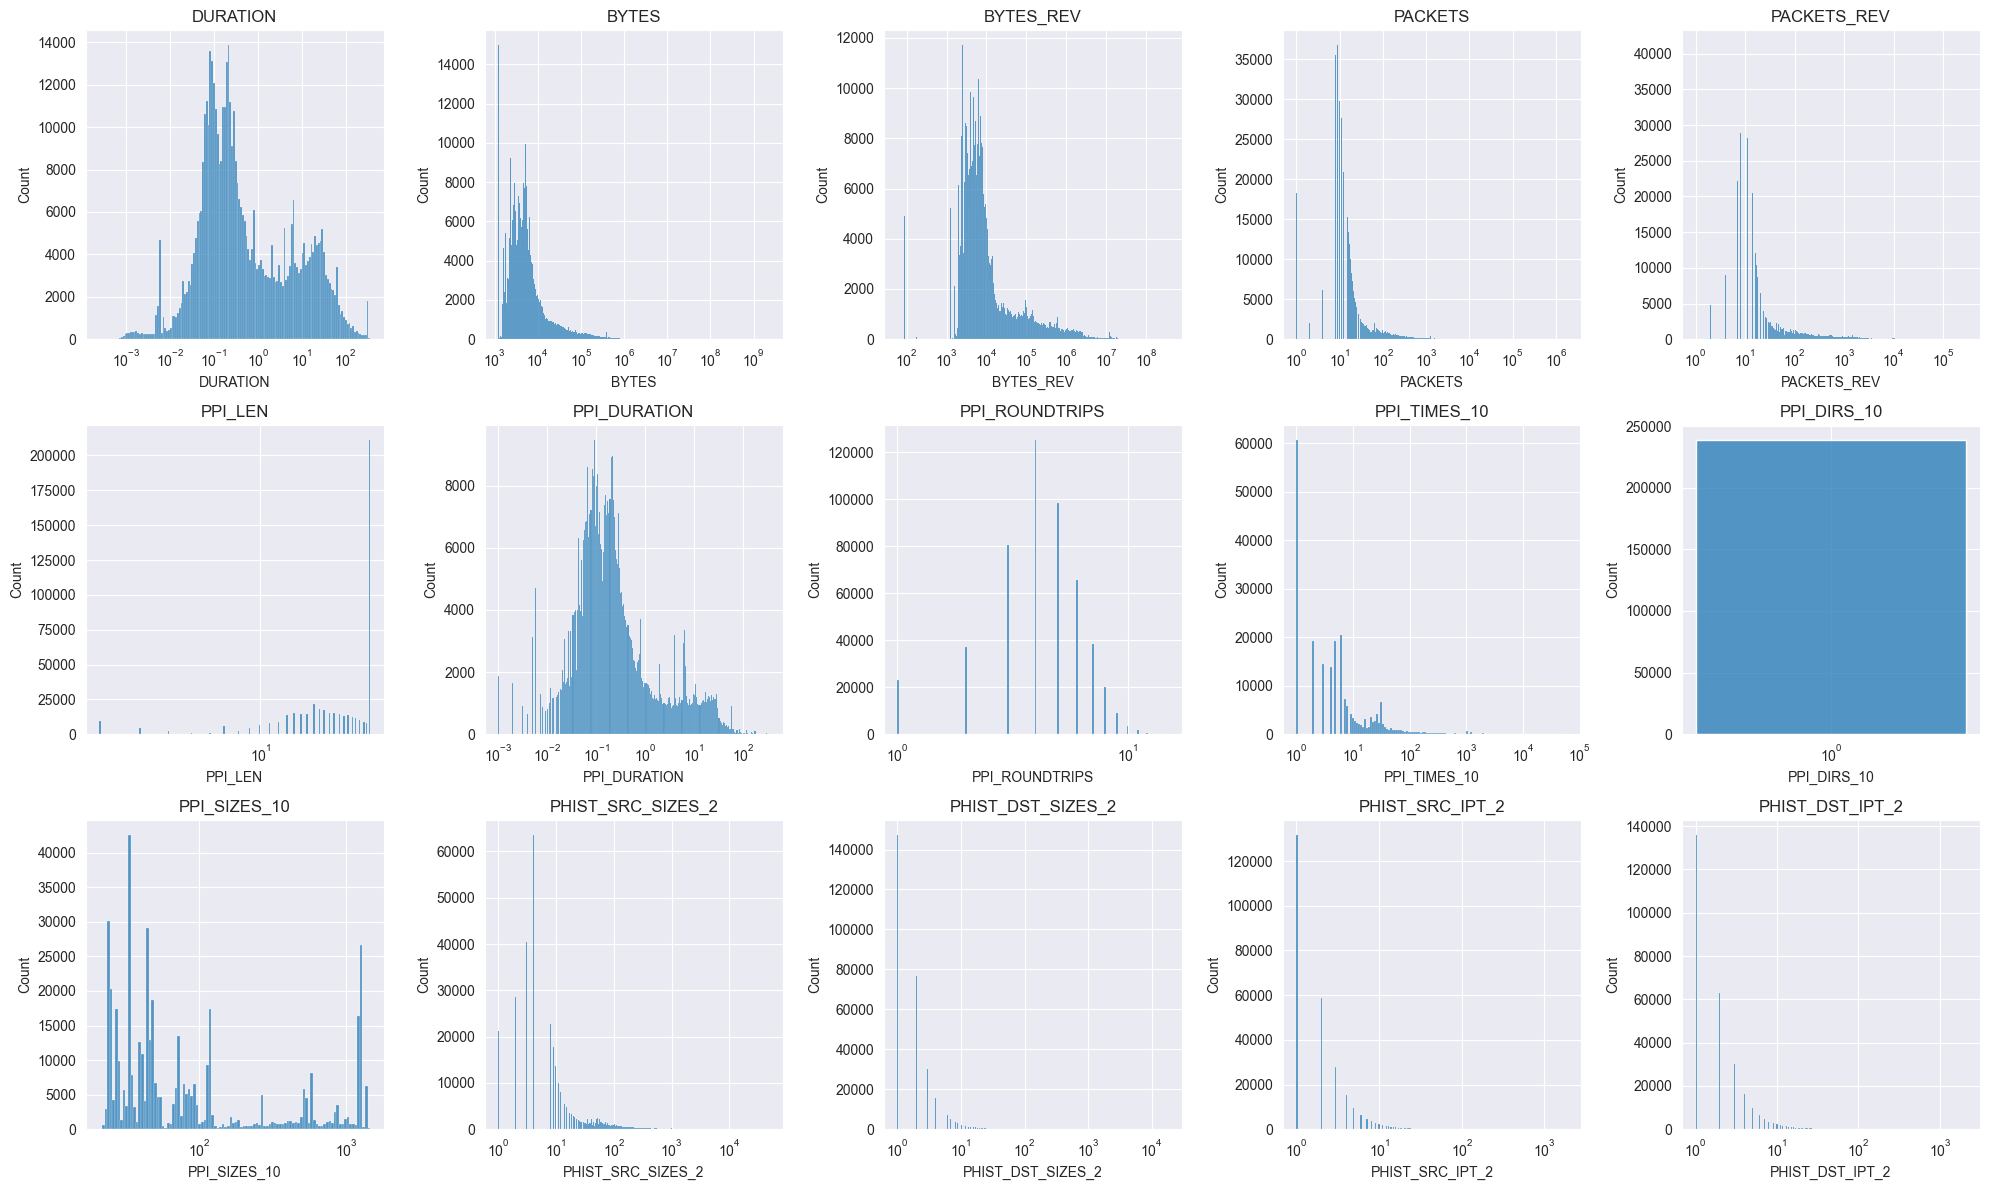

In [5]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engineering import Feature_Engineering

sample_week = pd.read_parquet('./duckdb/week_1_sampled.parquet')
fe = Feature_Engineering(sample_week)
pipeline_parse_cols(fe, sample_week, ppi_pad_len, phist_pad_len)
sample_week = fe.get_tabular_dataset()

ppi_sample_packet = math.floor(ppi_pad_len/3)
phist_sample_packet = math.floor(phist_pad_len/3)

numerical_cols = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS', f'PPI_TIMES_{ppi_sample_packet}', f'PPI_DIRS_{ppi_sample_packet}', f'PPI_SIZES_{ppi_sample_packet}', f'PHIST_SRC_SIZES_{phist_sample_packet}', f'PHIST_DST_SIZES_{phist_sample_packet}', f'PHIST_SRC_IPT_{phist_sample_packet}', f'PHIST_DST_IPT_{phist_sample_packet}']

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()  # now just a flat list of 15 slots

for i, col in enumerate(numerical_cols):
    sns.histplot(sample_week[col], kde=False, log_scale=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

##### Ostrates the scaling and encoding of each days dataset and saves them to ./tabular_dataset and ./sequential_dataset for ML models to use.

##### - tabular datasets contain all features + labels with PPI and PHIST array indices split into individual columns

##### - sequential datasets contain only PPI's + labels with each PPI as an array

In [6]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
import write_out
from feature_engineering import Feature_Engineering
import pandas as pd
import os

# Storing scaler and encoders for reverse_transform after
re = RobustScaler()
encoders_dict = {'label_encoder': {},
                 'RobustScaler': re}

for file in sorted(os.listdir('./duckdb')):
    if file.endswith('.parquet'):
        file_path = os.path.join('./duckdb', file)
        df = pd.read_parquet(file_path)
        print(f'{file}: {df.shape}')

        fe = Feature_Engineering(df)
        pipeline_parse_cols(fe, df, ppi_pad_len, phist_pad_len)

        is_week_1 =  "week_1" in file
        fe.perform_encode_and_scaling(encoders_dict, is_week_1)

        tabular_df = fe.get_tabular_dataset()
        write_out.write_out_tabular(tabular_df, file)


week_1_sampled.parquet: (503093, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_1_sampled.parquet
tabular_week_1_sampled.parquet: (503093, 135) saved to ./tabular_dataset/tabular_week_1_sampled.parquet
week_2_sampled.parquet: (510915, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_2_sampled.parquet
tabular_week_2_sampled.parquet: (510915, 135) saved to ./tabular_dataset/tabular_week_2_sampled.parquet
week_3_sampled.parquet: (502781, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_3_sampled.parquet
tabular_week_3_sampled.parquet: (502781, 135) saved to ./tabular_dataset/tabular_week_3_sampled.parquet
week_4_sampled.parquet: (511905, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust

### Datasets
- **Tabular with PPI** Flow stats + PHIST + PPI summary features (`PPI_LEN`, `PPI_DURATION`, `PPI_ROUNDTRIPS`)
- **Sequential PPI only** Raw PPI sequences only in sequential format

In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

tab_training_path = './tabular_dataset/tabular_week_1_sampled.parquet'
training_df = pd.read_parquet(tab_training_path)

flow_features = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV']
endreason_features = ['FLOW_ENDREASON_IDLE', 'FLOW_ENDREASON_ACTIVE', 'FLOW_ENDREASON_OTHER']
phist_features = [col for col in training_df if col.startswith('PHIST_')]
ppi_summary_features = ['PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS']
ppi_sequence_features = [col for col in training_df if col.startswith('PPI_') and col not in ppi_summary_features]

# Datasets splitting
best_model_y = training_df['APP']
best_model_X = training_df[flow_features + phist_features + endreason_features + ppi_summary_features + ppi_sequence_features]

bm_X_train, bm_X_test, bm_y_train, bm_y_test = train_test_split(best_model_X, best_model_y, test_size=0.3, random_state=42, stratify=best_model_y)

# Tabular Dataset Splits
tab_bm_X_train = bm_X_train.drop(columns=ppi_sequence_features)
tab_bm_X_test  = bm_X_test.drop(columns=ppi_sequence_features)
tab_bm_y_train = bm_y_train
tab_bm_y_test = bm_y_test

# Sequence Dataset Splits
def get_X_np_stacks() -> np.ndarray:
    seq_len = 30

    # For X train
    temp_train_df = bm_X_train.drop(columns=tab_cols)
    times = temp_train_df[[f'PPI_TIMES_{i}' for i in range(seq_len)]].values
    sizes = temp_train_df[[f'PPI_SIZES_{i}' for i in range(seq_len)]].values
    dirs = temp_train_df[[f'PPI_DIRS_{i}' for i in range(seq_len)]].values
    seq_X_train = np.stack([times, sizes, dirs], axis=2)  # (n, 30, 3)

    # For X test
    temp_test_df = bm_X_test.drop(columns=tab_cols)
    times = temp_test_df[[f'PPI_TIMES_{i}' for i in range(seq_len)]].values
    sizes = temp_test_df[[f'PPI_SIZES_{i}' for i in range(seq_len)]].values
    dirs = temp_test_df[[f'PPI_DIRS_{i}' for i in range(seq_len)]].values
    seq_X_test = np.stack([times, sizes, dirs], axis=2)  # (n, 30, 3)
    return seq_X_train, seq_X_test

num_classes = len(np.unique(best_model_y.values))
seq_len = 30
num_features = 3
tab_cols = flow_features + phist_features + endreason_features + ppi_summary_features
seq_bm_X_train, seq_bm_X_test = get_X_np_stacks()
seq_bm_y_train = bm_y_train.values
seq_bm_y_test = bm_y_test.values

#### Timer class for model training and predicting times

In [8]:
import time
class Timer:
    def __init__(self):
        self.start_ts = time.time()
    def stop(self):
        self.end_ts = time.time()
        mins, secs = divmod(self.end_ts - self.start_ts, 60)
        print(f'Time Elapsed: {mins}m {secs}s')

#### Evaluation class for evaluating each model

In [9]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class Evaluate_model:
    def __init__(self, y_true, y_pred, modelname: str):
        self.y_true = y_true
        self.y_pred = y_pred
        self.modelname = modelname
        try:
            self.class_names = encoders_dict["label_encoder"]["APP"].classes_
        except (KeyError, AttributeError):
            self.class_names = None

    # Prints accuracy, macro f1, weighted f1 and classification report to console
    def get_main_metrics(self):
        acc         = accuracy_score(self.y_true, self.y_pred)
        macro_f1    = f1_score(self.y_true, self.y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(self.y_true, self.y_pred, average="weighted", zero_division=0)

        print(f"------- {self.modelname} -------")
        print(f"Accuracy    : {acc:.4f}")
        print(f"Macro F1    : {macro_f1:.4f}")
        print(f"Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(self.y_true, self.y_pred, target_names=self.class_names, zero_division=0))

    # Prints confusion matrix of top n / bottom n peforming classes
    def get_confusion_matrix(self, on_top: bool, num=10):
        per_class_f1 = f1_score(self.y_true, self.y_pred, average=None, zero_division=0)
        if on_top:
            idx = np.argsort(per_class_f1)[-num:][::-1]
            label = f"top {num} best"
        else:
            idx = np.argsort(per_class_f1)[:num]
            label = f"bottom {num} worst"
        cm      = confusion_matrix(self.y_true, self.y_pred, labels=idx)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        tick_labels = [self.class_names[i] for i in idx] if self.class_names is not None else idx

        fig, ax = plt.subplots(figsize=(18, 15))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=tick_labels, yticklabels=tick_labels, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"{self.modelname} — Normalised Confusion Matrix ({label} performing classes by F1)")
        plt.xticks(rotation=45, ha="right", fontsize=8)
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()
        print("\n")


### Random Forest: Hypertuning Parameters
#### 20% Sample Test - 50 trials

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import optuna
import gc
from sklearn.ensemble import RandomForestClassifier

# 20% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    tab_bm_X_train, tab_bm_y_train, train_size=0.20, random_state=42, stratify=tab_bm_y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 400, step=100),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_depth=trial.suggest_int("max_depth", 10, 35),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=10,
    )
    model = RandomForestClassifier(**params)
    model.fit(X_sub_tr, y_sub_tr)
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    del model
    gc.collect()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=50, timeout=1200)

print(f"Completed {len(study.trials)} trials")
print("Best params:", study.best_params)
print("Best val F1:", study.best_value)

[I 2026-04-17 10:39:29,380] A new study created in memory with name: no-name-a9b8bd35-0960-49c7-9093-ef18fd64c5cf
[I 2026-04-17 10:39:32,255] Trial 0 finished with value: 0.49598672784185777 and parameters: {'n_estimators': 200, 'max_features': 'log2', 'min_samples_leaf': 5, 'max_depth': 10, 'max_samples': 0.5527123151991691}. Best is trial 0 with value: 0.49598672784185777.
[I 2026-04-17 10:39:34,508] Trial 1 finished with value: 0.6416006827986085 and parameters: {'n_estimators': 100, 'max_features': 'log2', 'min_samples_leaf': 2, 'max_depth': 16, 'max_samples': 0.6590029767562868}. Best is trial 1 with value: 0.6416006827986085.
[I 2026-04-17 10:39:41,885] Trial 2 finished with value: 0.575537246582819 and parameters: {'n_estimators': 100, 'max_features': 0.7, 'min_samples_leaf': 15, 'max_depth': 17, 'max_samples': 0.7217663647648456}. Best is trial 1 with value: 0.6416006827986085.
[I 2026-04-17 10:40:15,541] Trial 3 finished with value: 0.6302703250644923 and parameters: {'n_estim

Completed 50 trials
Best params: {'n_estimators': 300, 'max_features': 0.5, 'min_samples_leaf': 1, 'max_depth': 25, 'max_samples': 0.8641205605159896}
Best val F1: 0.6943903283068951


#### 50% Sample Test - top 5 trials

In [11]:
# 50% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    tab_bm_X_train, tab_bm_y_train, train_size=0.5, random_state=42, stratify=tab_bm_y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

# Pull top 5 trials from Stage 1 by value
top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]

results = []
for trial in top_trials:
    params = trial.params
    model = RandomForestClassifier(
        **params,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=10,
    )
    model.fit(X_sub_tr, y_sub_tr)
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    results.append((score, trial.number, params))
    del model
    print(f"Trial {trial.number:>3} | Stage1 F1: {trial.value:.4f} | Stage2 F1: {score:.4f}")

# Best confirmed params
best_score, best_trial_num, best_params = max(results, key=lambda x: x[0])
print(f"\nBest confirmed: Trial {best_trial_num} — Stage2 F1: {best_score:.4f}")
print("Params:", best_params)

Trial  12 | Stage1 F1: 0.6944 | Stage2 F1: 0.7408
Trial  47 | Stage1 F1: 0.6930 | Stage2 F1: 0.7435
Trial  14 | Stage1 F1: 0.6926 | Stage2 F1: 0.7433
Trial  21 | Stage1 F1: 0.6924 | Stage2 F1: 0.7434
Trial  13 | Stage1 F1: 0.6923 | Stage2 F1: 0.7417

Best confirmed: Trial 47 — Stage2 F1: 0.7435
Params: {'n_estimators': 300, 'max_features': 0.5, 'min_samples_leaf': 1, 'max_depth': 32, 'max_samples': 0.903278171144037}


#### Best Random Forest Model Training on Week 1

Time Elapsed: 5.0m 4.784206867218018s
------- Random Forest Week 1 -------
Accuracy    : 0.7795
Macro F1    : 0.7739
Weighted F1 : 0.7763
                       precision    recall  f1-score   support

                4chan       0.67      0.77      0.71      1500
              adavoid       0.87      0.91      0.89      1500
        alza-identity       0.73      0.61      0.66       743
          alza-webapi       0.81      0.82      0.81      1500
             alza-www       0.57      0.60      0.58      1500
   apple-privaterelay       0.97      0.99      0.98      1500
   bitdefender-nimbus       0.90      0.88      0.89       843
                bitly       0.87      0.88      0.88      1500
             blitz-gg       0.83      0.81      0.82      1500
              blogger       0.62      0.63      0.62      1500
              cedexis       0.88      0.89      0.88      1500
            chess-com       0.58      0.43      0.49      1500
 chrome-remotedesktop       0.97      0.98

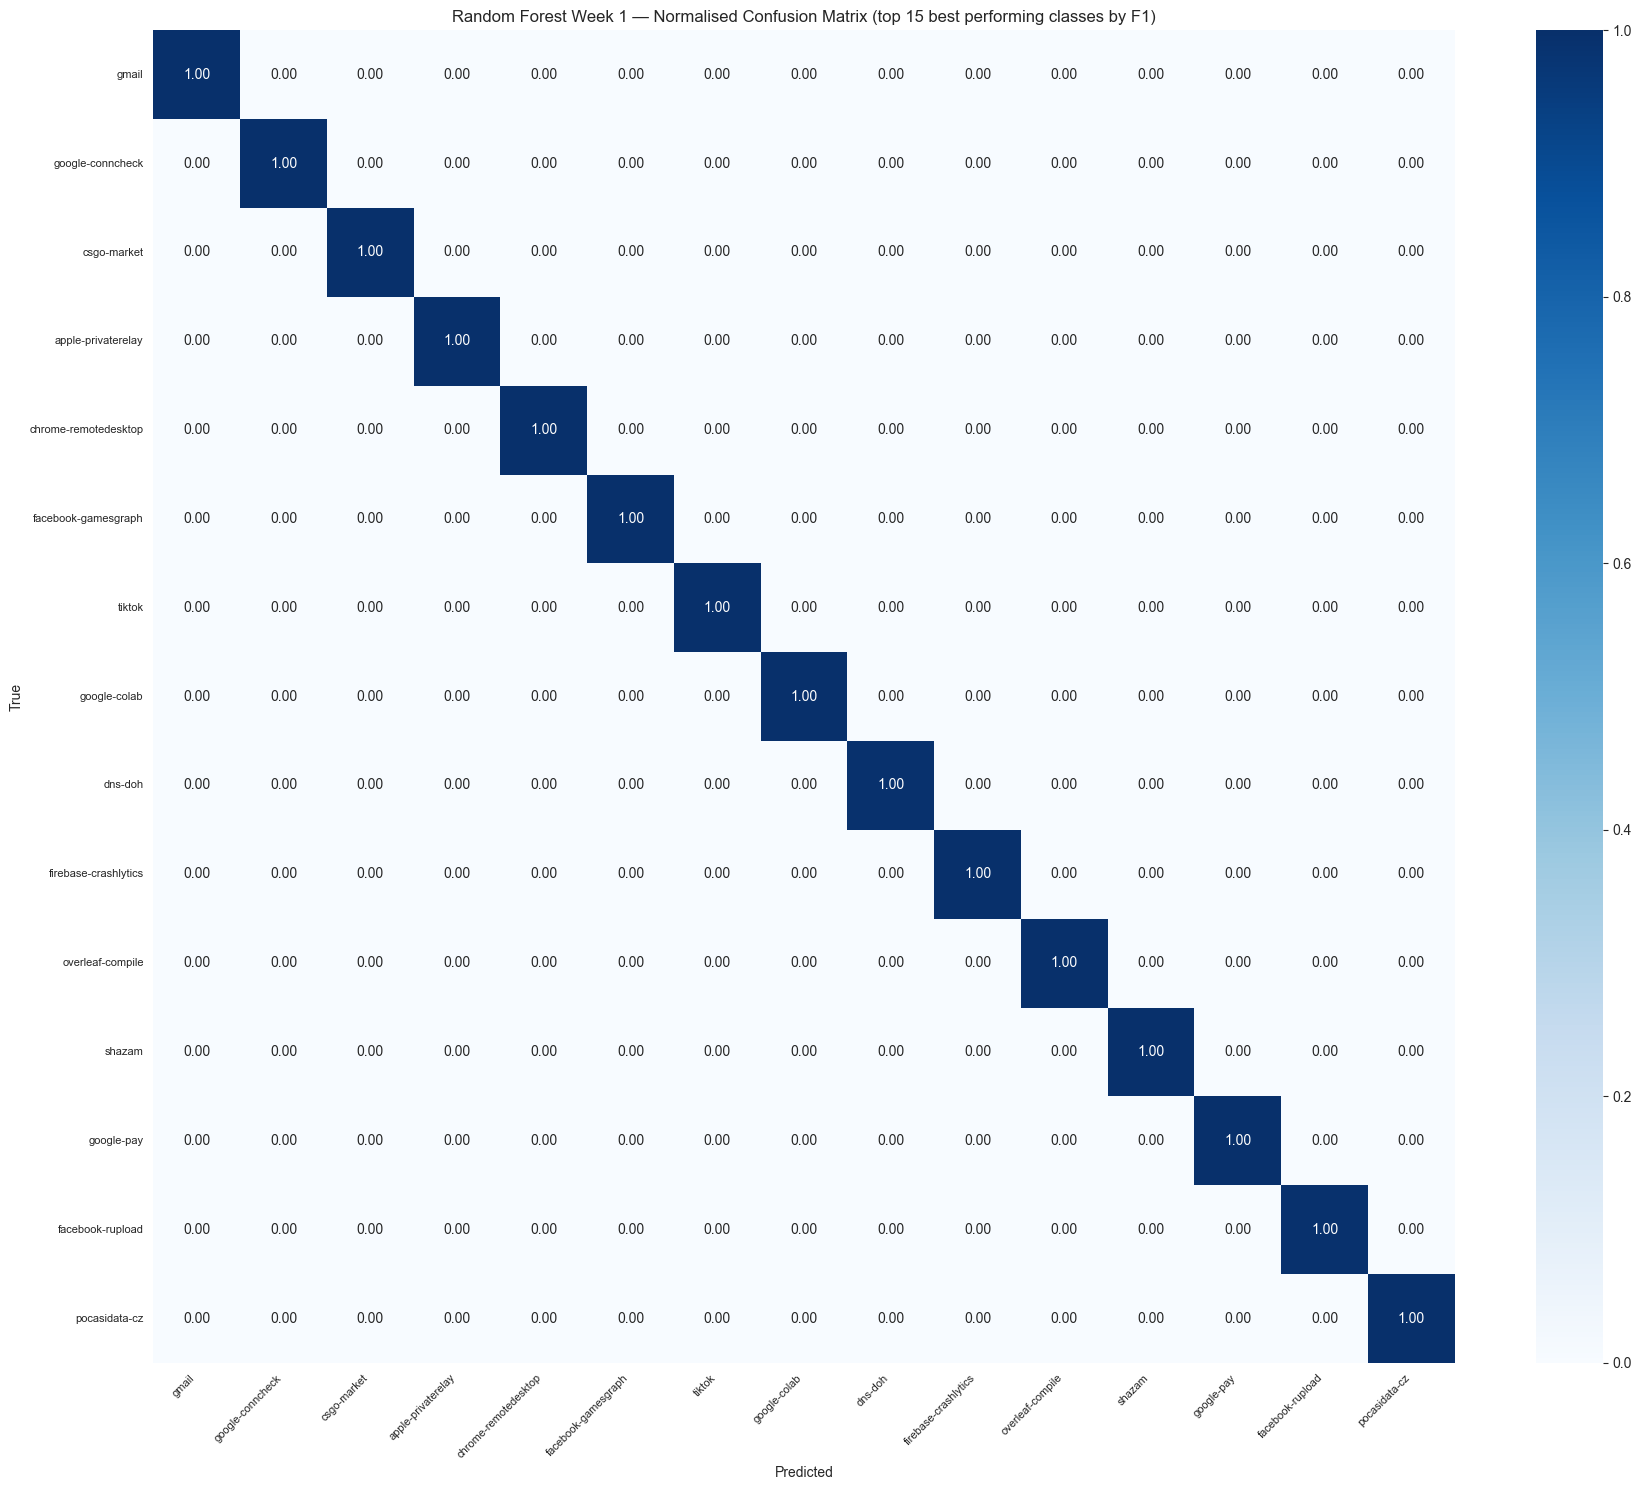

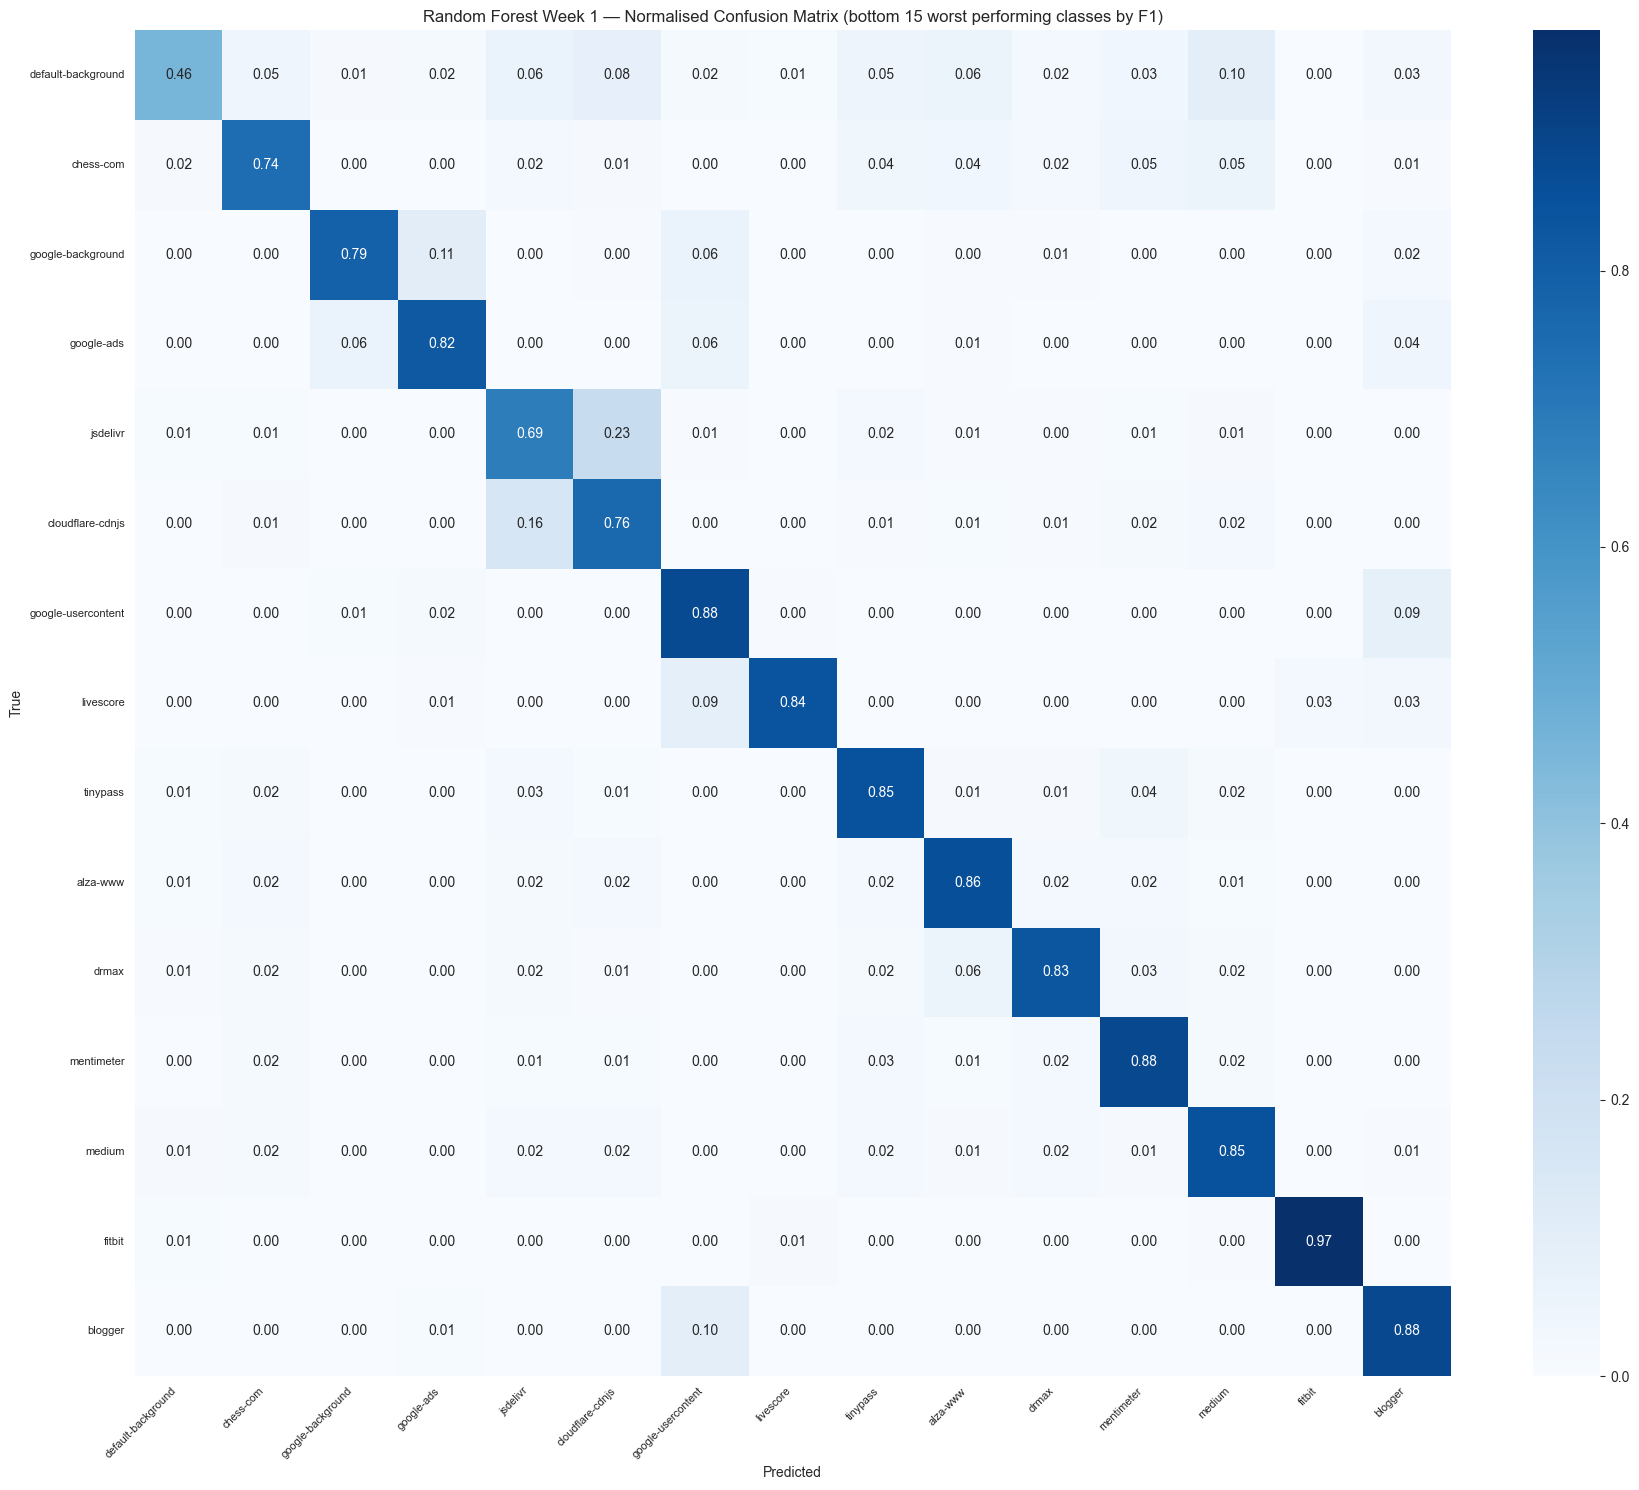



------------------------------------------------------------



In [12]:
import gc

# Free stage-2 models before the full fit
del results
gc.collect()

rf = RandomForestClassifier(
    **best_params,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=10,
)

timer = Timer()

rf.fit(tab_bm_X_train, tab_bm_y_train)

y_pred = rf.predict(tab_bm_X_test)

timer.stop()

rf_results = Evaluate_model(y_true=tab_bm_y_test, y_pred=y_pred, modelname=f'Random Forest Week 1')
rf_results.get_main_metrics()
rf_results.get_confusion_matrix(on_top=True, num=15)
rf_results.get_confusion_matrix(on_top=False, num=15)
print('------------------------------------------------------------\n')

#### Best Random Forest Prediction: Week 2, Week 3 and Week 4

Time Elapsed: 2.0m 3.303711175918579s
------- Random Forest week_2 -------
Accuracy    : 0.7433
Macro F1    : 0.7388
Weighted F1 : 0.7406
                       precision    recall  f1-score   support

                4chan       0.64      0.71      0.67      5000
              adavoid       0.84      0.81      0.83      5000
        alza-identity       0.79      0.68      0.73      2730
          alza-webapi       0.81      0.82      0.82      5000
             alza-www       0.53      0.58      0.55      5000
   apple-privaterelay       0.97      0.99      0.98      5000
   bitdefender-nimbus       0.88      0.87      0.87      4128
                bitly       0.84      0.85      0.84      5000
             blitz-gg       0.83      0.78      0.80      5000
              blogger       0.57      0.61      0.59      5000
              cedexis       0.85      0.87      0.86      5000
            chess-com       0.59      0.45      0.51      5000
 chrome-remotedesktop       0.96      0.86

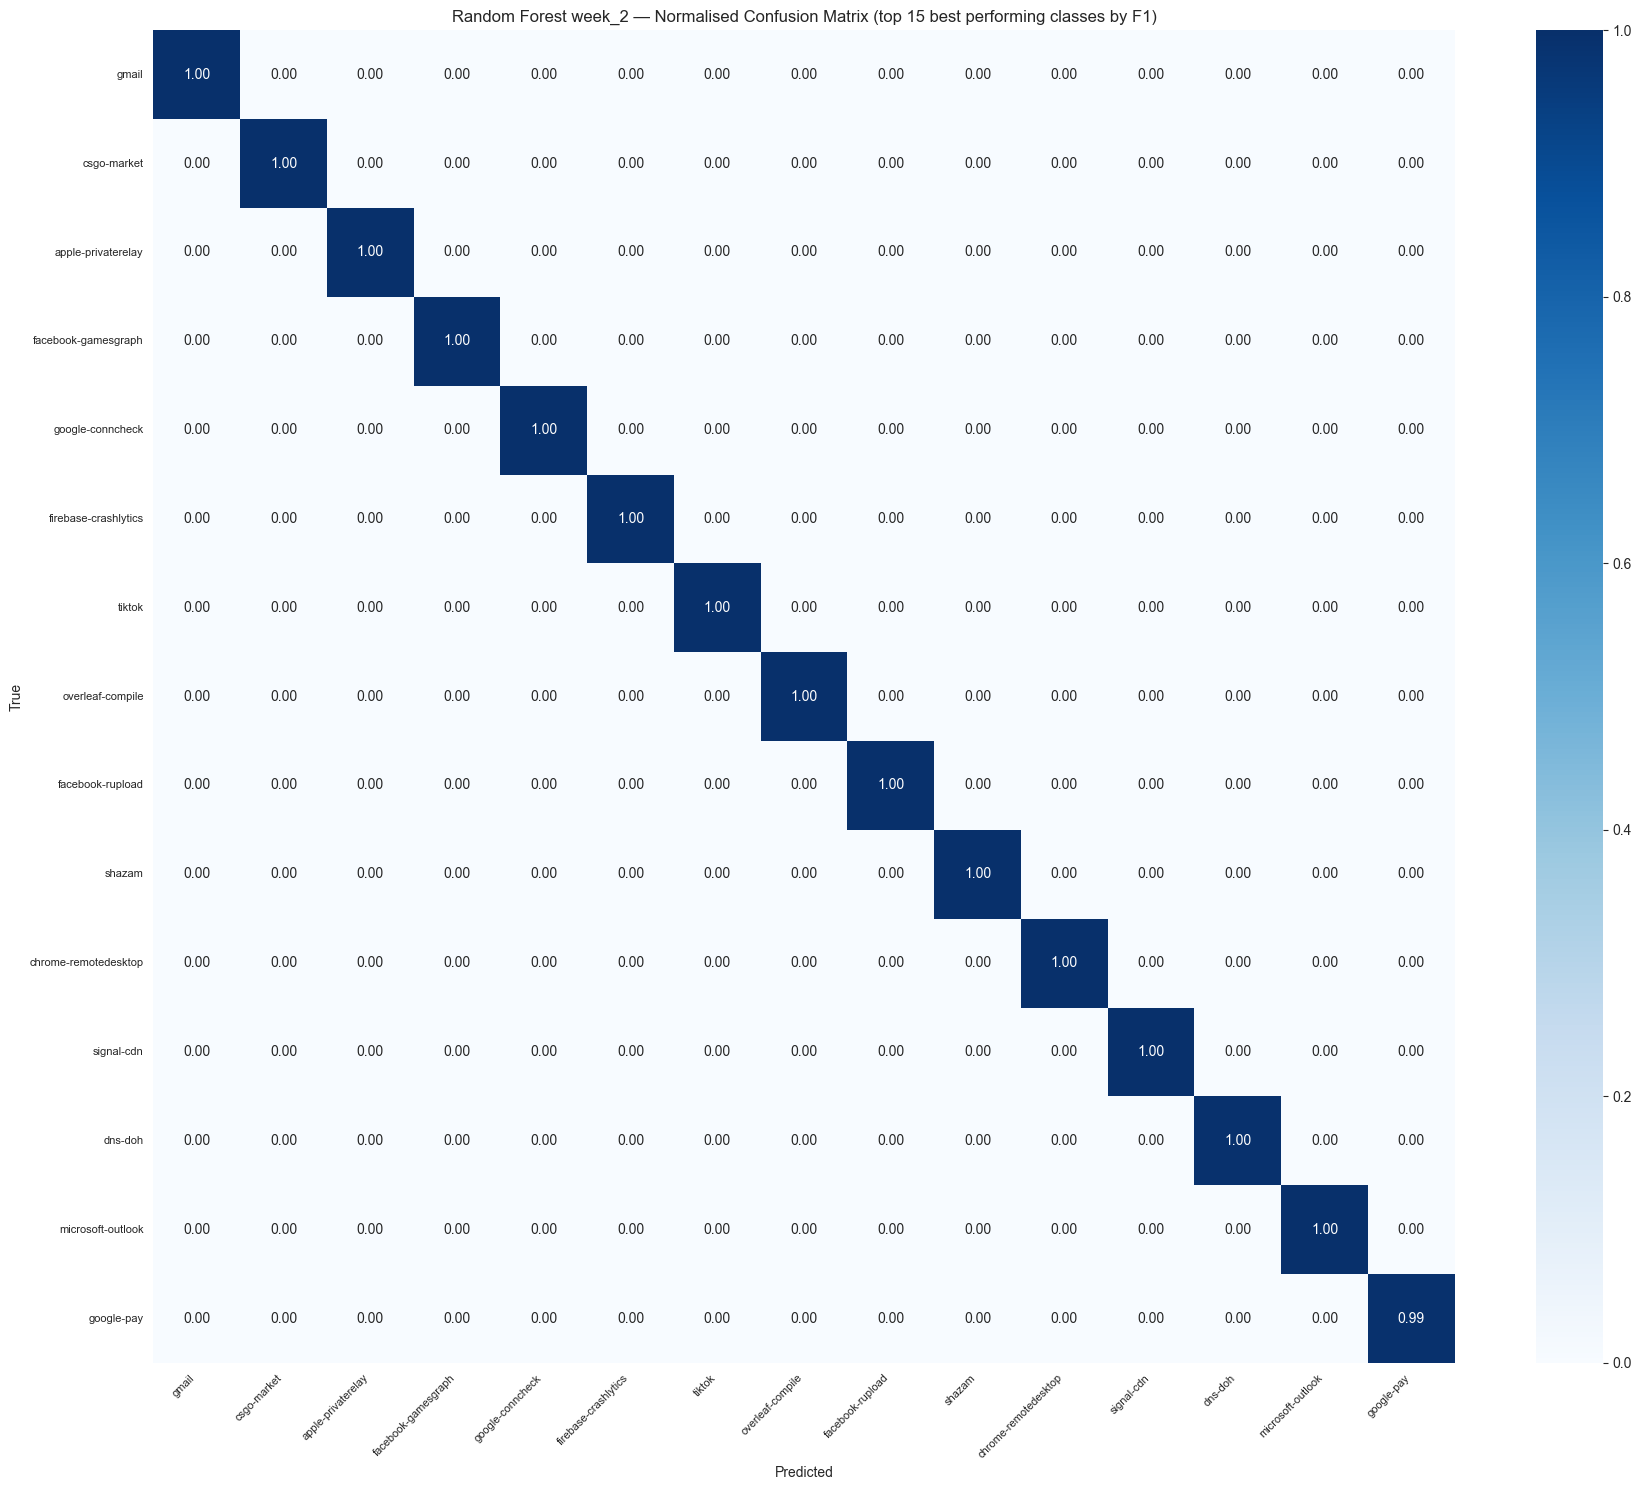

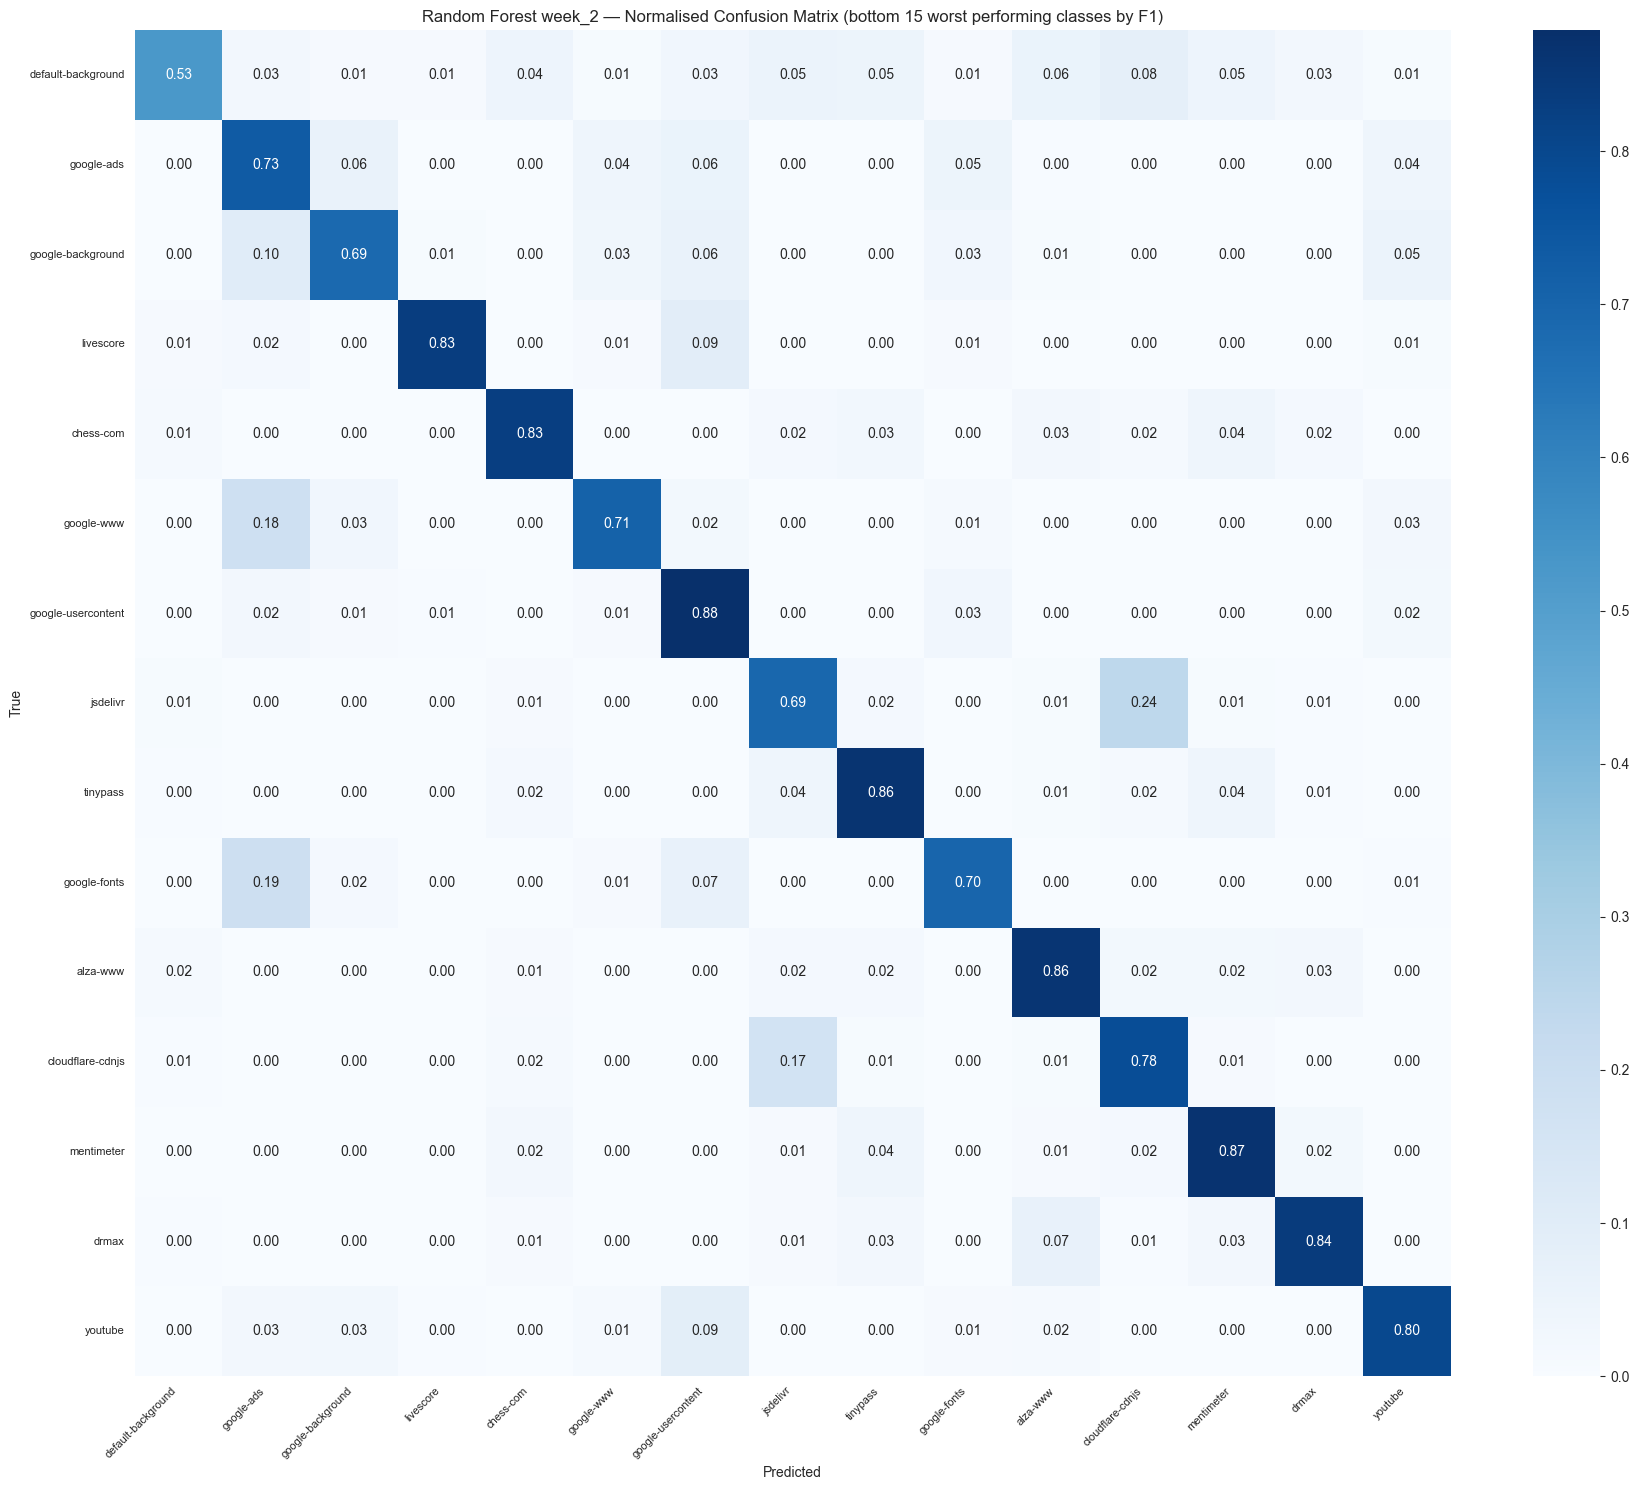



------------------------------------------------------------

Time Elapsed: 1.0m 26.240381717681885s
------- Random Forest week_3 -------
Accuracy    : 0.7099
Macro F1    : 0.7010
Weighted F1 : 0.7033
                       precision    recall  f1-score   support

                4chan       0.65      0.76      0.70      5000
              adavoid       0.80      0.73      0.77      5000
        alza-identity       0.74      0.67      0.70      2355
          alza-webapi       0.80      0.82      0.81      5000
             alza-www       0.52      0.56      0.54      5000
   apple-privaterelay       0.97      0.99      0.98      5000
   bitdefender-nimbus       0.76      0.85      0.80      2276
                bitly       0.83      0.88      0.86      5000
             blitz-gg       0.79      0.72      0.75      5000
              blogger       0.52      0.58      0.55      5000
              cedexis       0.87      0.89      0.88      5000
            chess-com       0.55      0.

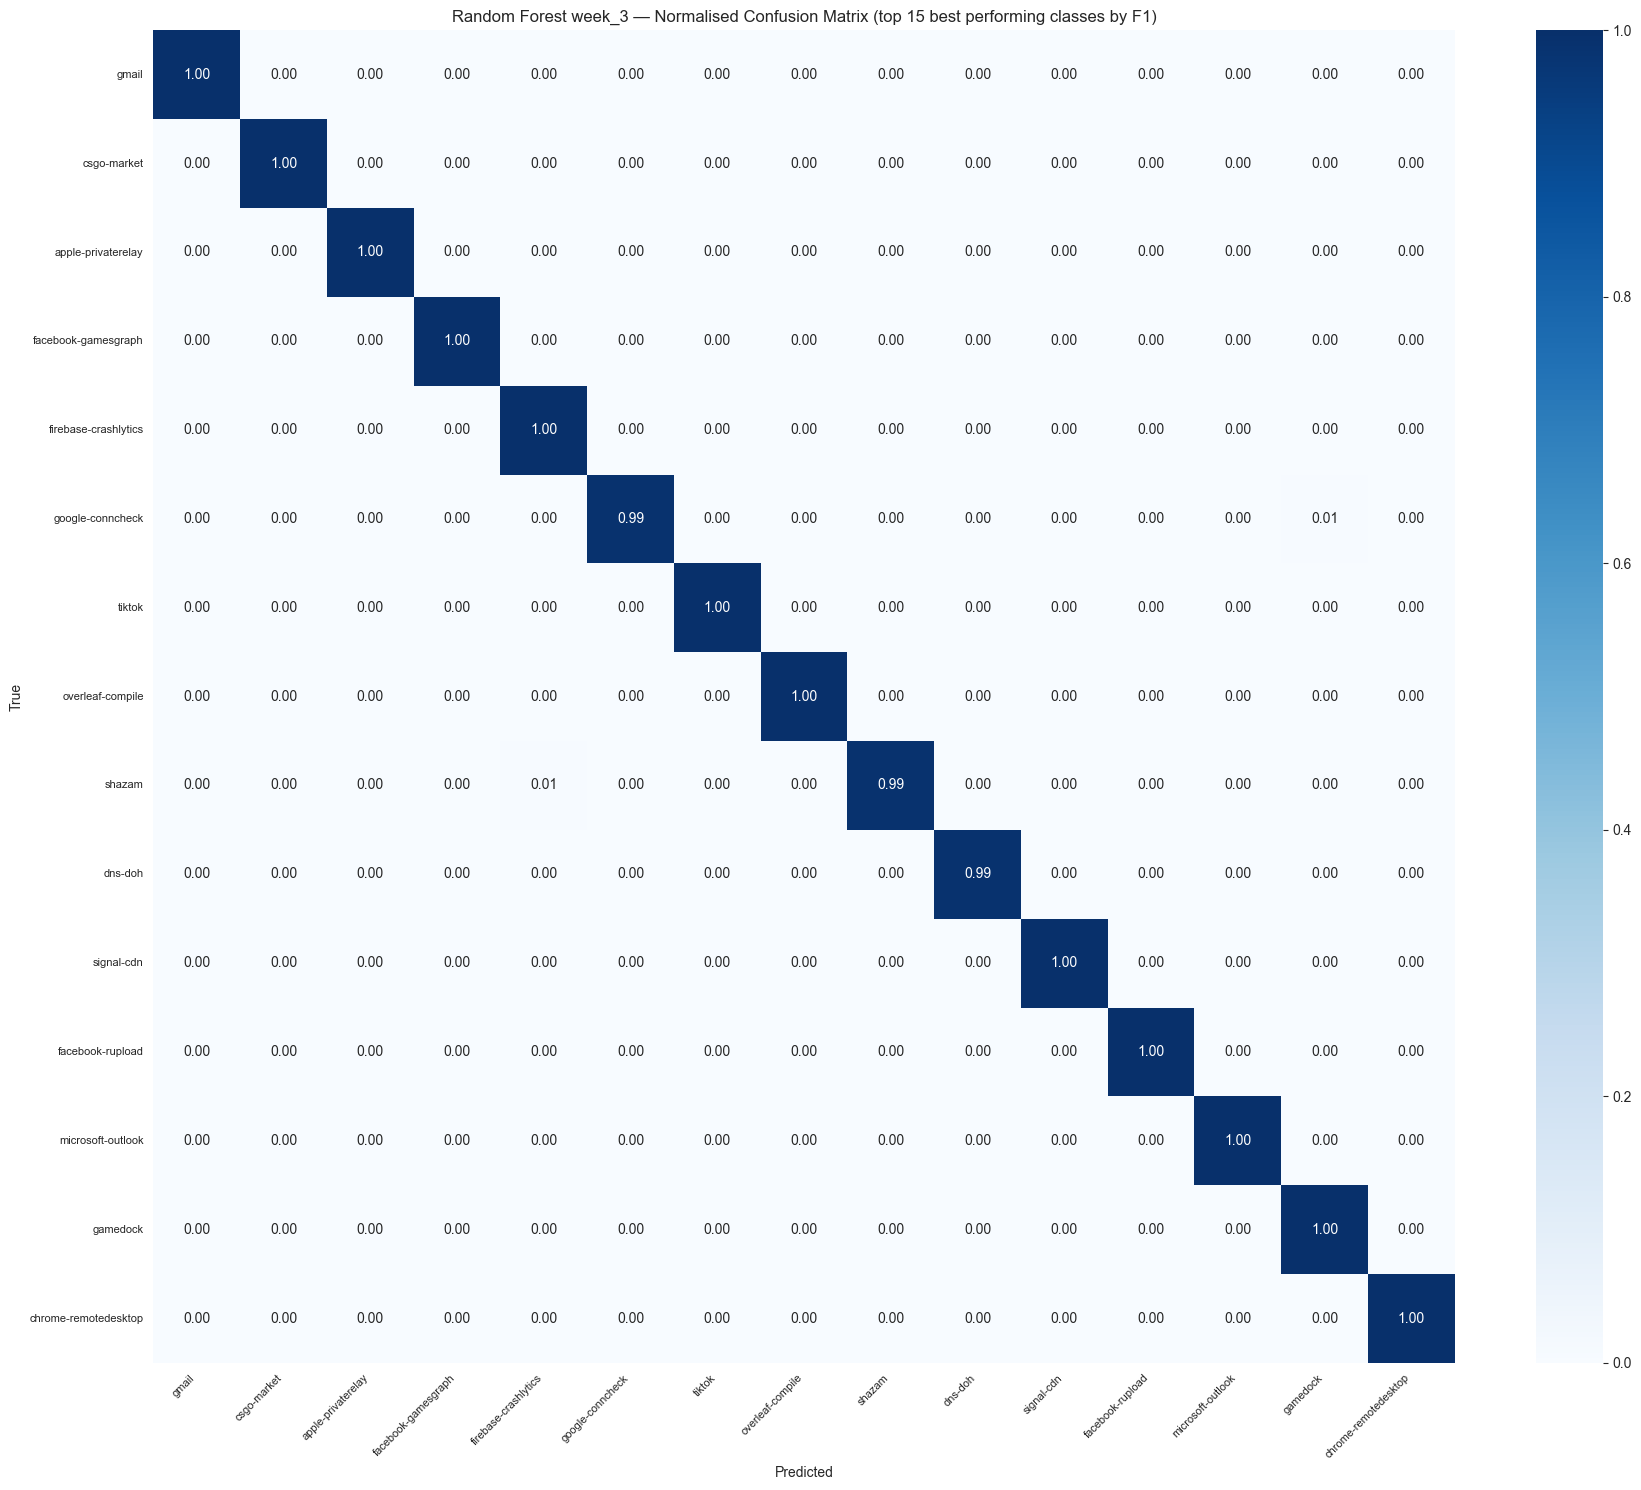

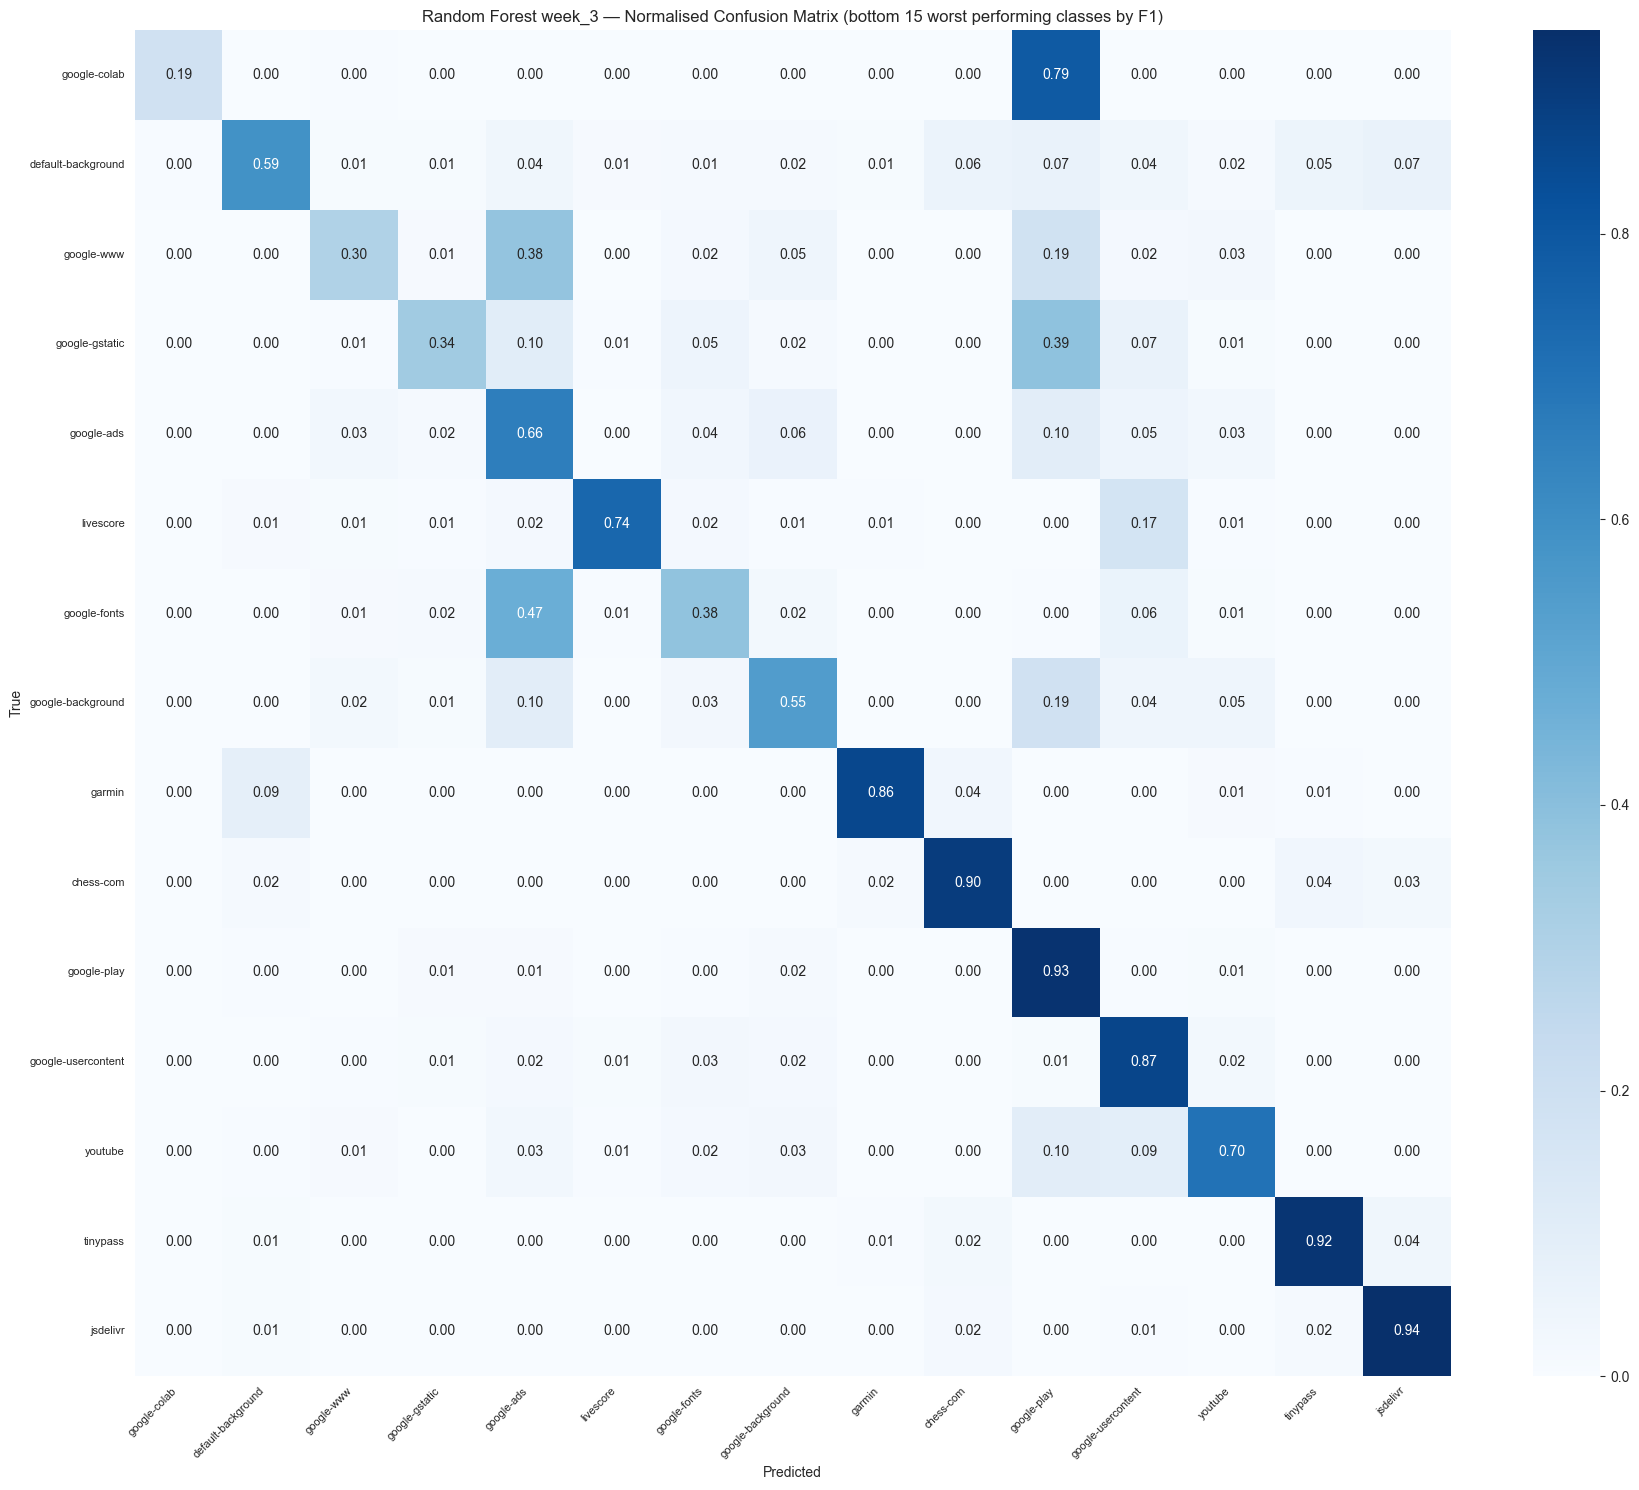



------------------------------------------------------------

Time Elapsed: 1.0m 20.466702222824097s
------- Random Forest week_4 -------
Accuracy    : 0.7049
Macro F1    : 0.6976
Weighted F1 : 0.6972
                       precision    recall  f1-score   support

                4chan       0.63      0.74      0.68      5000
              adavoid       0.85      0.91      0.88      5000
        alza-identity       0.78      0.68      0.73      3049
          alza-webapi       0.78      0.81      0.79      5000
             alza-www       0.53      0.57      0.55      5000
   apple-privaterelay       0.97      0.99      0.98      5000
   bitdefender-nimbus       0.79      0.86      0.82      2782
                bitly       0.82      0.85      0.83      5000
             blitz-gg       0.77      0.65      0.71      5000
              blogger       0.50      0.59      0.54      5000
              cedexis       0.84      0.89      0.86      5000
            chess-com       0.55      0.

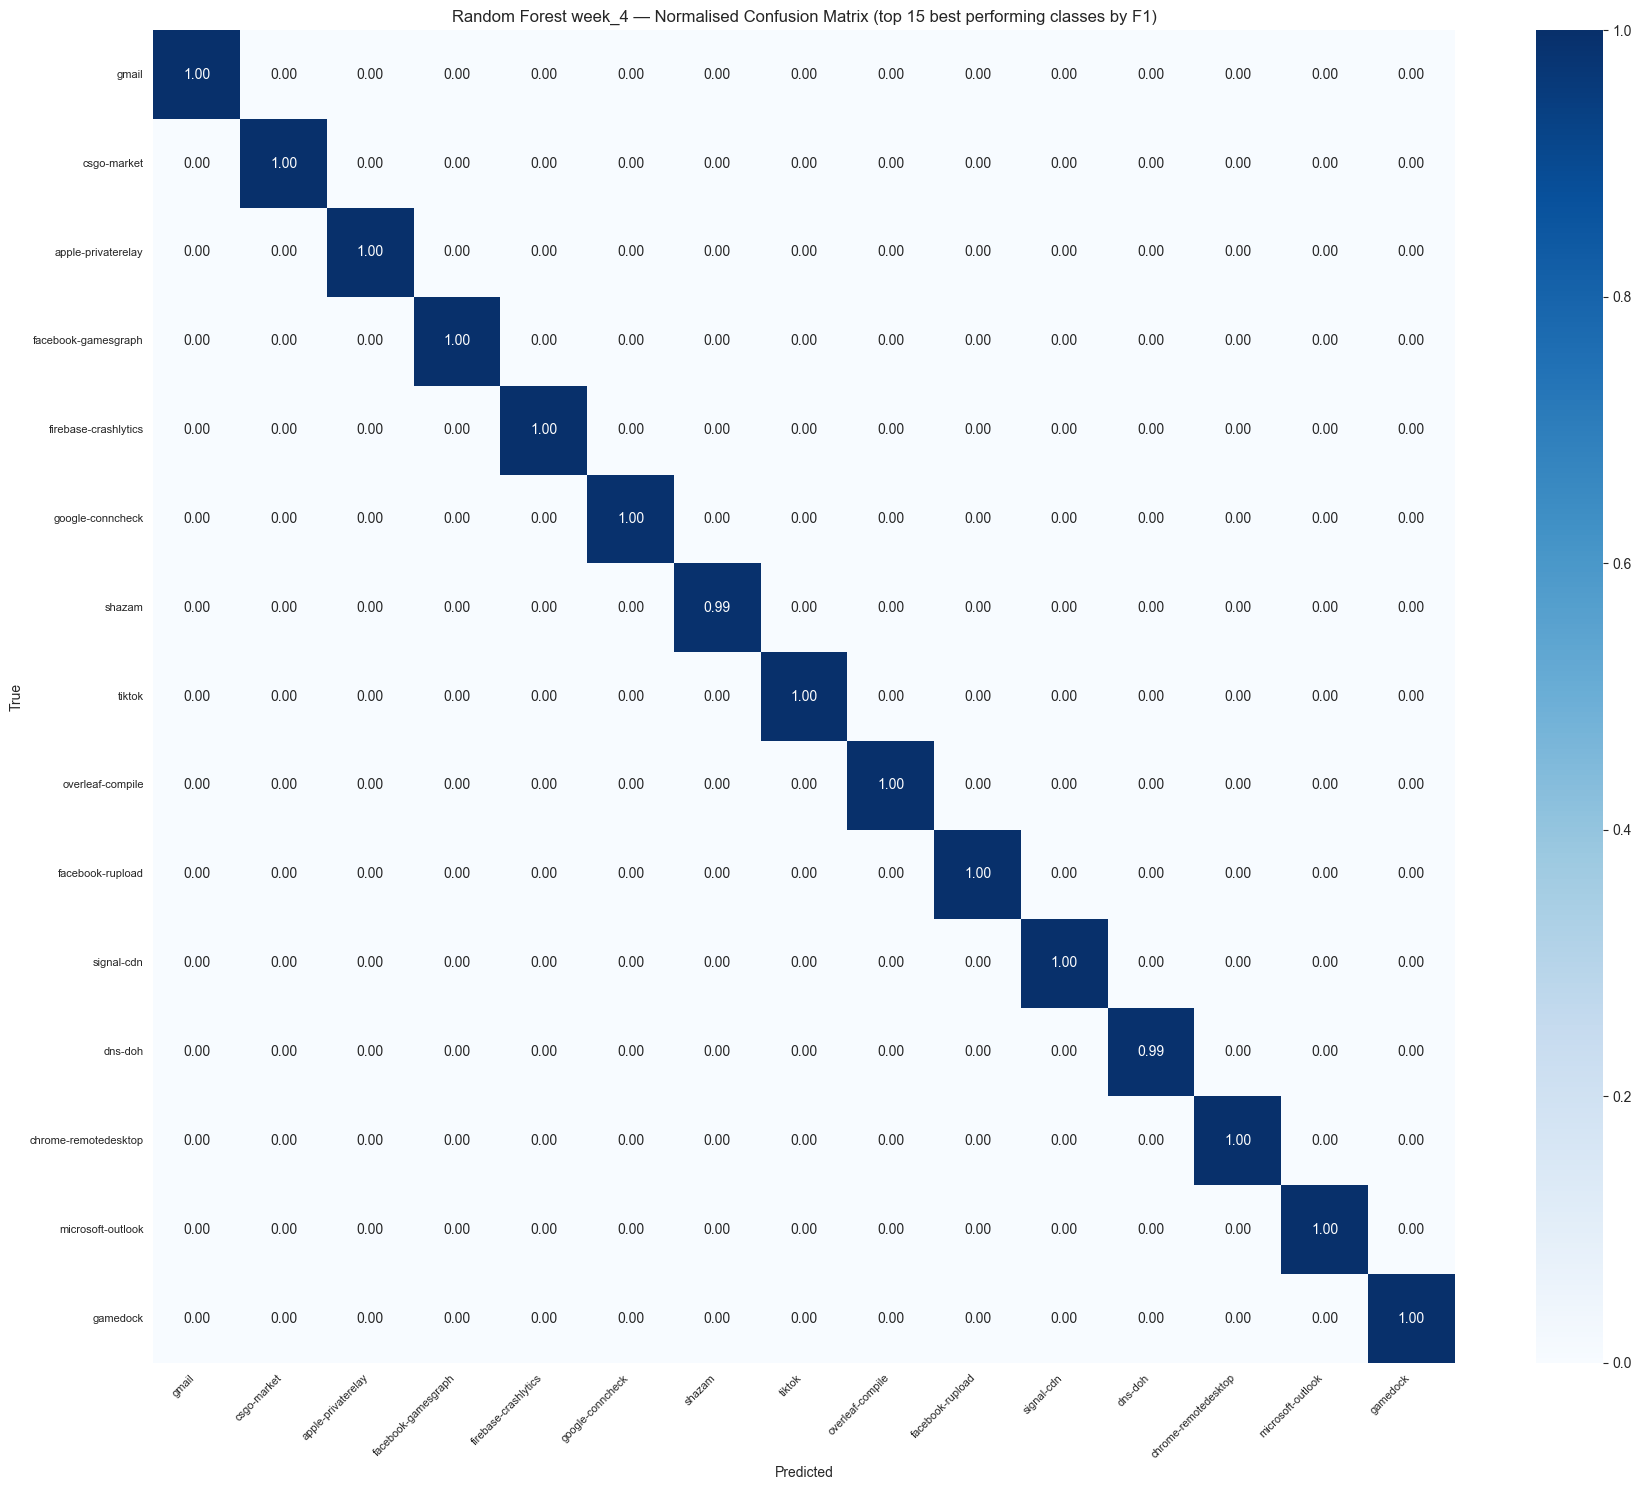

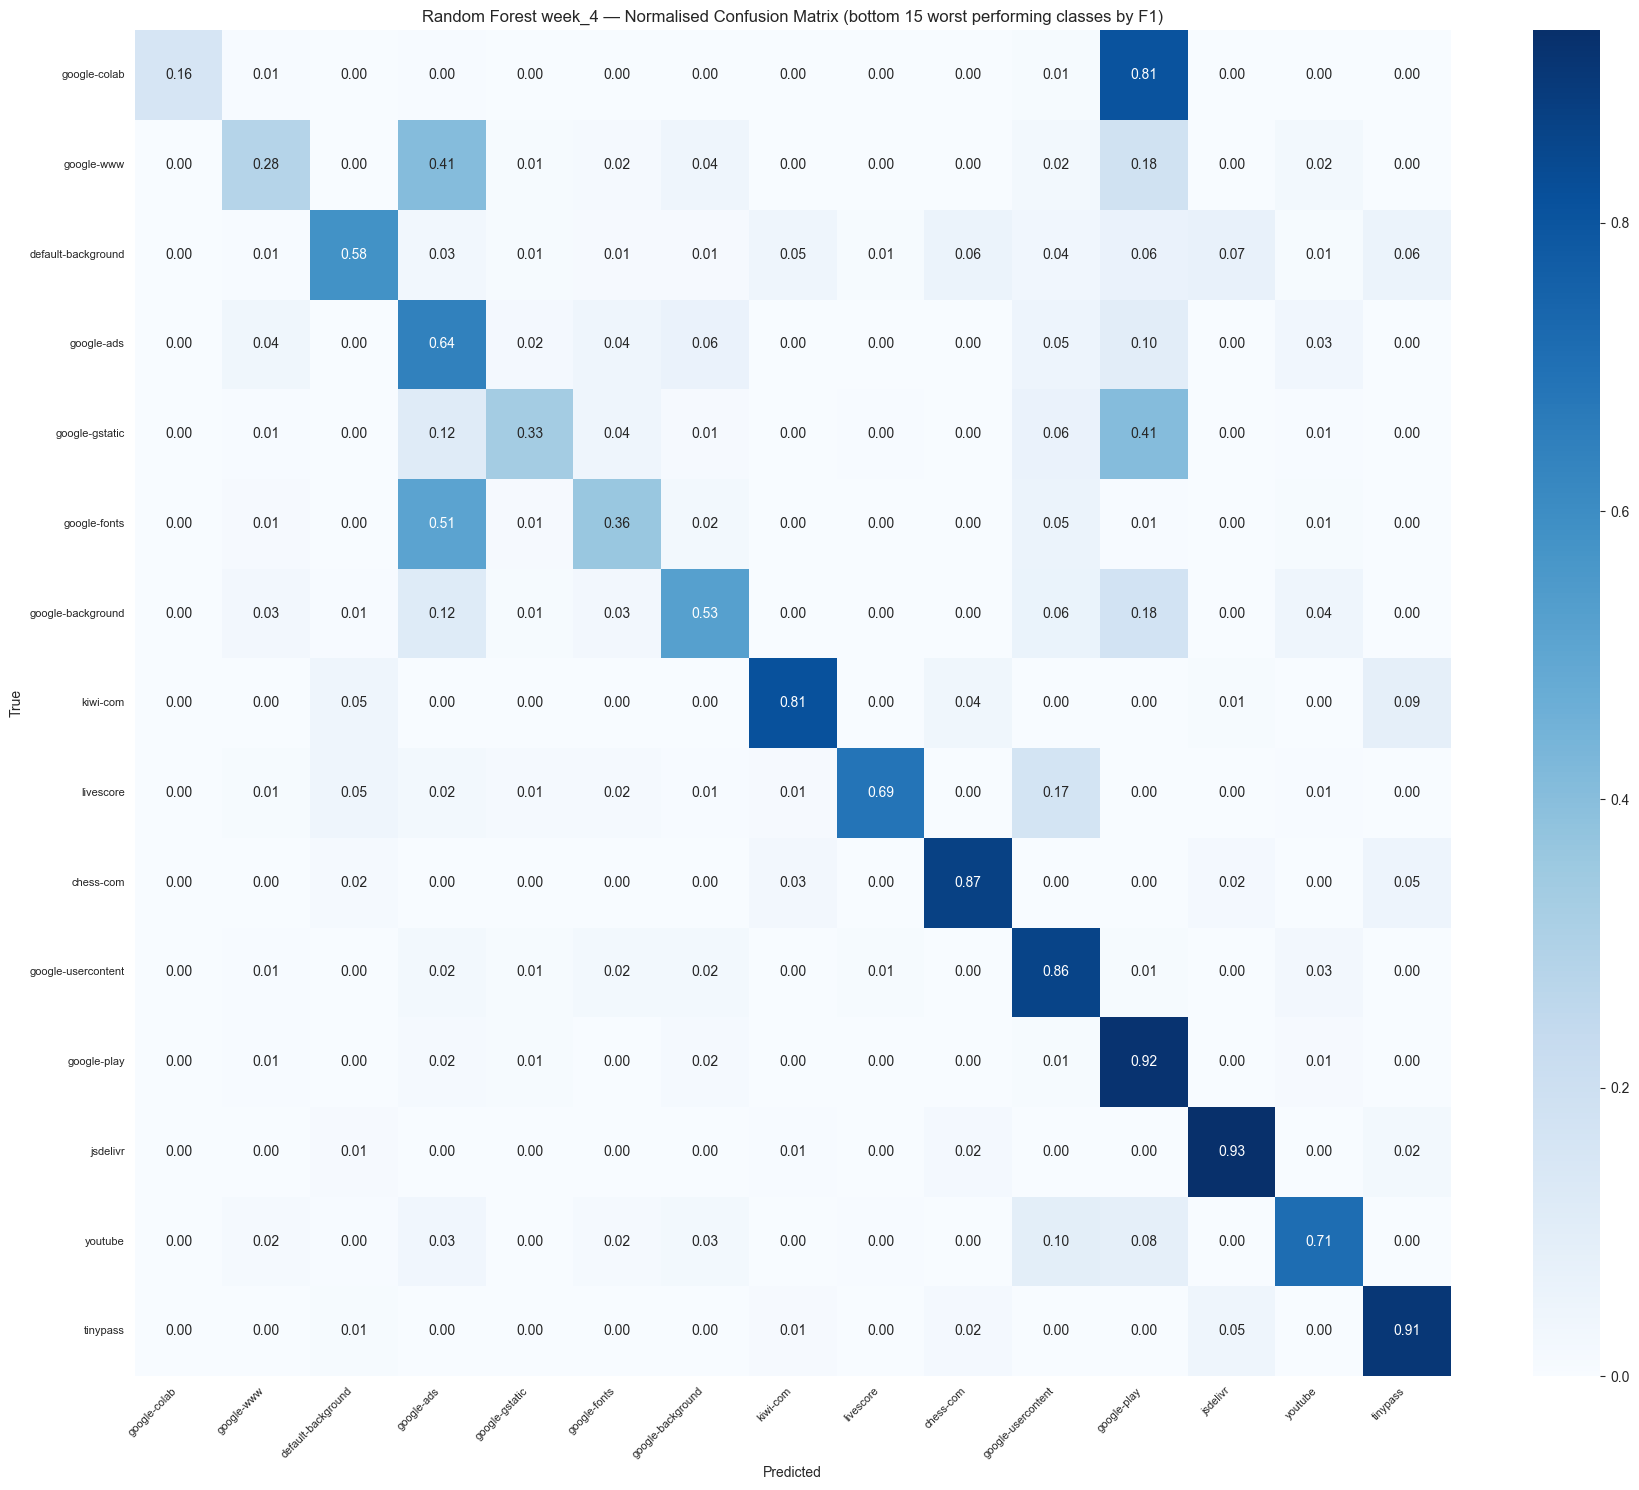



------------------------------------------------------------



In [13]:
import numpy as np

weeks_to_test = {
    'week_2': './tabular_dataset/tabular_week_2_sampled.parquet',
    'week_3': './tabular_dataset/tabular_week_3_sampled.parquet',
    'week_4': './tabular_dataset/tabular_week_4_sampled.parquet',
}

BATCH = 10_000

for week, path in weeks_to_test.items():
    current_week_df = pd.read_parquet(path)
    X = current_week_df[flow_features + phist_features + endreason_features + ppi_summary_features]
    y = current_week_df['APP']

    timer = Timer()

    preds = []
    for start in range(0, len(X), BATCH):
        preds.append(rf.predict(X.iloc[start:start + BATCH]))
    y_pred = np.concatenate(preds)

    timer.stop()

    evaluate_model = Evaluate_model(y_true=y, y_pred=y_pred, modelname=f'Random Forest {week}')
    evaluate_model.get_main_metrics()
    evaluate_model.get_confusion_matrix(on_top=True, num=15)
    evaluate_model.get_confusion_matrix(on_top=False, num=15)
    print('------------------------------------------------------------\n')

### Lightgbm: Hypertuning Parameters
#### 20% Sample Test - 50 trials

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import optuna
import lightgbm as lgb
import gc

# 20% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    tab_bm_X_train, tab_bm_y_train, train_size=0.20, random_state=42, stratify=tab_bm_y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

def objective_lightgbm(trial):
    params = dict(
        n_estimators=100,
        num_leaves=trial.suggest_int("num_leaves", 31, 127),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        max_bin=255,
        force_col_wise=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=10,
        verbose=-1,
    )
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_sub_tr, y_sub_tr,
        eval_set=[(X_sub_test, y_sub_test)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)], # Preventing overfitting on test data by later rounds
    )
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    del model
    gc.collect()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective_lightgbm, n_trials=50, timeout=1200)

print(f"Completed {len(study.trials)} trials")
print("Best params:", study.best_params)
print("Best val F1:", study.best_value)


[I 2026-04-17 11:12:52,757] A new study created in memory with name: no-name-421c8240-6bcb-4f8b-a453-658580ed9470
[I 2026-04-17 11:13:28,208] Trial 0 finished with value: 0.6890171626076929 and parameters: {'num_leaves': 53, 'learning_rate': 0.03500989369275821, 'min_child_samples': 30, 'subsample': 0.8780484317093875, 'colsample_bytree': 0.8349421747646978, 'reg_lambda': 0.6058955225264898}. Best is trial 0 with value: 0.6890171626076929.
[I 2026-04-17 11:13:56,373] Trial 1 finished with value: 0.6840857389301548 and parameters: {'num_leaves': 32, 'learning_rate': 0.05293798655455627, 'min_child_samples': 7, 'subsample': 0.8781011713520921, 'colsample_bytree': 0.6769560248346889, 'reg_lambda': 0.7351501803410802}. Best is trial 0 with value: 0.6890171626076929.
[I 2026-04-17 11:14:23,562] Trial 2 finished with value: 0.6700602754873084 and parameters: {'num_leaves': 34, 'learning_rate': 0.061089458455355065, 'min_child_samples': 8, 'subsample': 0.8752330563547425, 'colsample_bytree': 

Completed 33 trials
Best params: {'num_leaves': 71, 'learning_rate': 0.08422024764695032, 'min_child_samples': 7, 'subsample': 0.8873210640919547, 'colsample_bytree': 0.6689076849096333, 'reg_lambda': 0.9763718387451374}
Best val F1: 0.6960188418328643


#### 50% Sample Test - top 5 trials

In [15]:
# 50% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    tab_bm_X_train, tab_bm_y_train, train_size=0.50, random_state=42, stratify=tab_bm_y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

# Pull top 5 trials from Stage 1 by value
top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]

results = []
for trial in top_trials:
    params = trial.params
    model = lgb.LGBMClassifier(
        **params,
        n_estimators=200,
        max_bin=255,
        force_col_wise=True,
        class_weight='balanced',
        random_state=42,
        n_jobs=10,
        verbose=1,
    )
    model.fit(
        X_sub_tr, y_sub_tr,
        eval_set=[(X_sub_test, y_sub_test)],
        callbacks=[lgb.early_stopping(30, verbose=True), lgb.log_evaluation(-1)],
    )
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    results.append((score, trial.number, params))
    del model
    gc.collect()
    print(f"Trial {trial.number:>3} | Stage1 F1: {trial.value:.4f} | Stage2 F1: {score:.4f}")

# Best confirmed params
best_score, best_trial_num, best_params = max(results, key=lambda x: x[0])
print(f"\nBest confirmed: Trial {best_trial_num} — Stage2 F1: {best_score:.4f}")
print("Params:", best_params)

[LightGBM] [Info] Total Bins 6464
[LightGBM] [Info] Number of data points in the train set: 149669, number of used features: 41
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGB

#### Best Light GBM Model Training on Week 1

[LightGBM] [Info] Total Bins 6690
[LightGBM] [Info] Number of data points in the train set: 352165, number of used features: 41
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGBM] [Info] Start training from score -4.653960
[LightGB

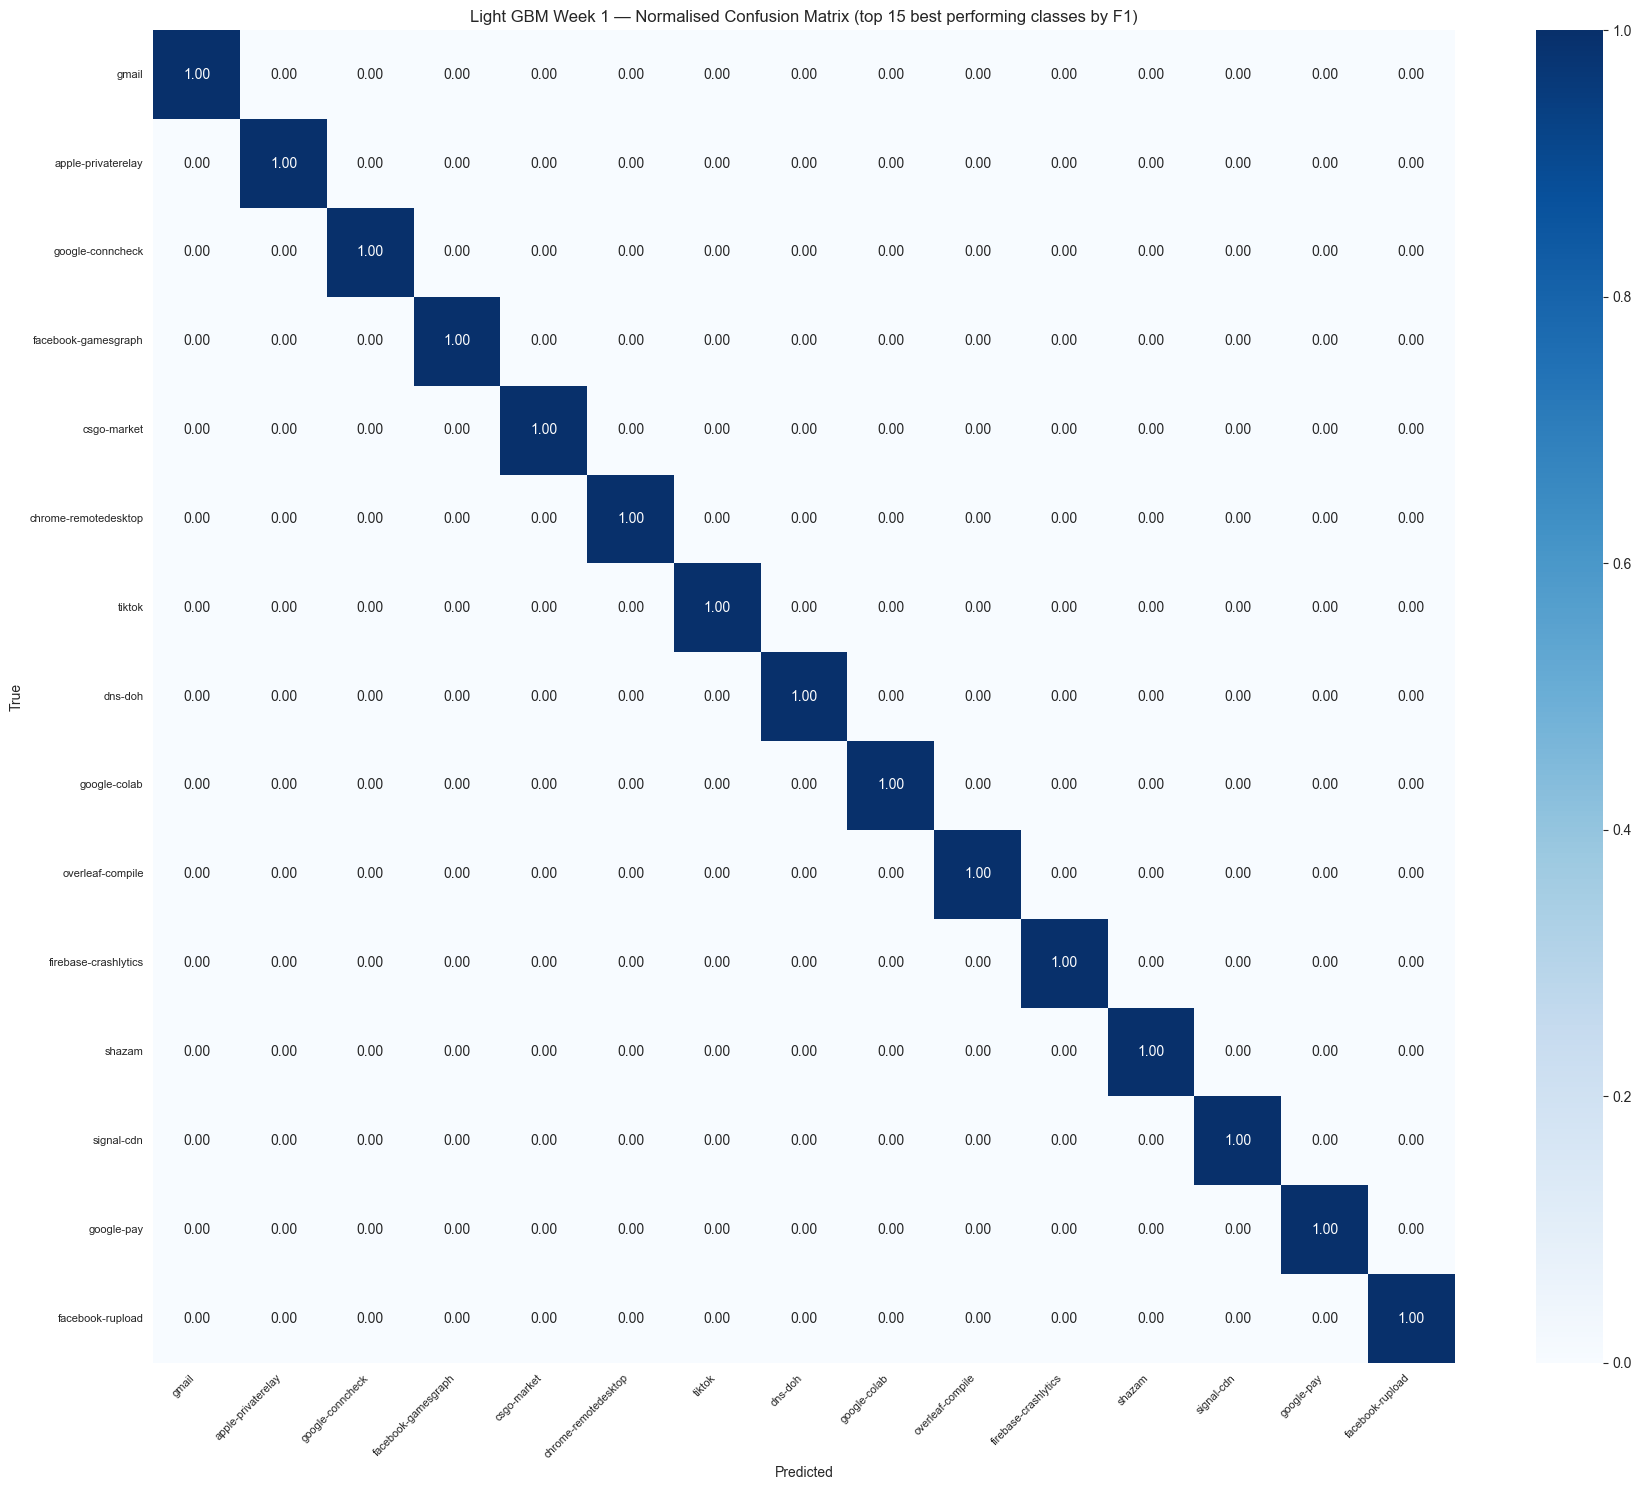

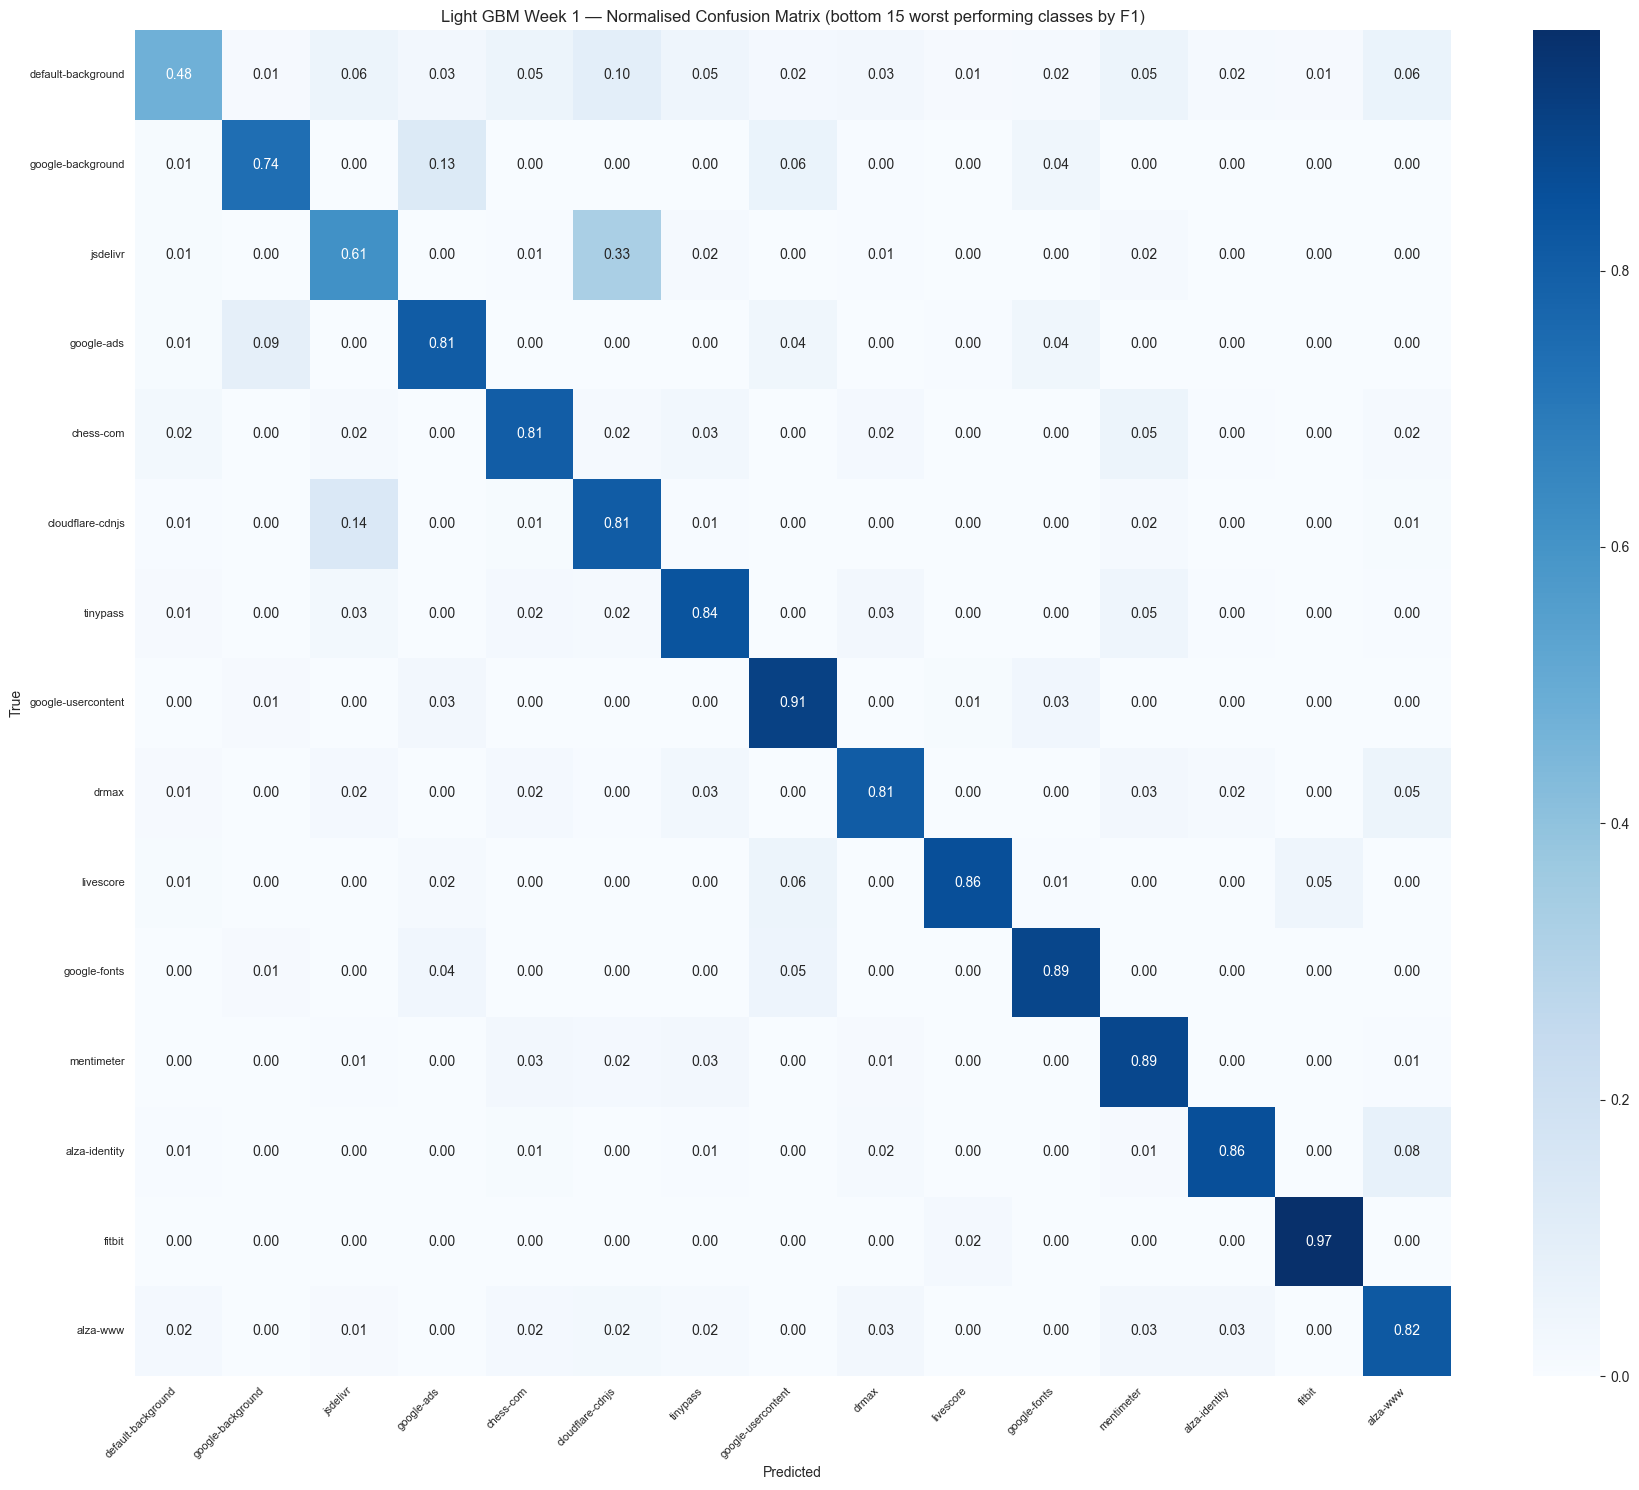



------------------------------------------------------------



In [16]:
lightgbm = lgb.LGBMClassifier(
      **best_params,
      n_estimators=300,
      max_bin=255,
      force_col_wise=True,
      class_weight="balanced",
      random_state=42,
      n_jobs=10,
      verbose=1,
  )

timer = Timer()

lightgbm.fit(
      tab_bm_X_train, tab_bm_y_train,
      eval_set=[(tab_bm_X_test, tab_bm_y_test)],
      callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(-1)],
  )

y_pred = lightgbm.predict(tab_bm_X_test)

timer.stop()

lightgbm_results = Evaluate_model(y_true=tab_bm_y_test, y_pred=y_pred, modelname=f'Light GBM Week 1')
lightgbm_results.get_main_metrics()
lightgbm_results.get_confusion_matrix(on_top=True, num=15)
lightgbm_results.get_confusion_matrix(on_top=False, num=15)
print('------------------------------------------------------------\n')


#### Best Light GBM Model Prediction: Week 2, Week 3 and Week 4

Time Elapsed: 5.0m 29.46666669845581s
------- Light GBM week_2 -------
Accuracy    : 0.7525
Macro F1    : 0.7512
Weighted F1 : 0.7530
                       precision    recall  f1-score   support

                4chan       0.67      0.68      0.67      5000
              adavoid       0.82      0.82      0.82      5000
        alza-identity       0.63      0.69      0.66      2730
          alza-webapi       0.80      0.81      0.80      5000
             alza-www       0.56      0.60      0.58      5000
   apple-privaterelay       0.99      0.99      0.99      5000
   bitdefender-nimbus       0.92      0.88      0.90      4128
                bitly       0.88      0.84      0.86      5000
             blitz-gg       0.85      0.78      0.82      5000
              blogger       0.61      0.64      0.63      5000
              cedexis       0.92      0.87      0.89      5000
            chess-com       0.53      0.49      0.51      5000
 chrome-remotedesktop       0.98      0.94    

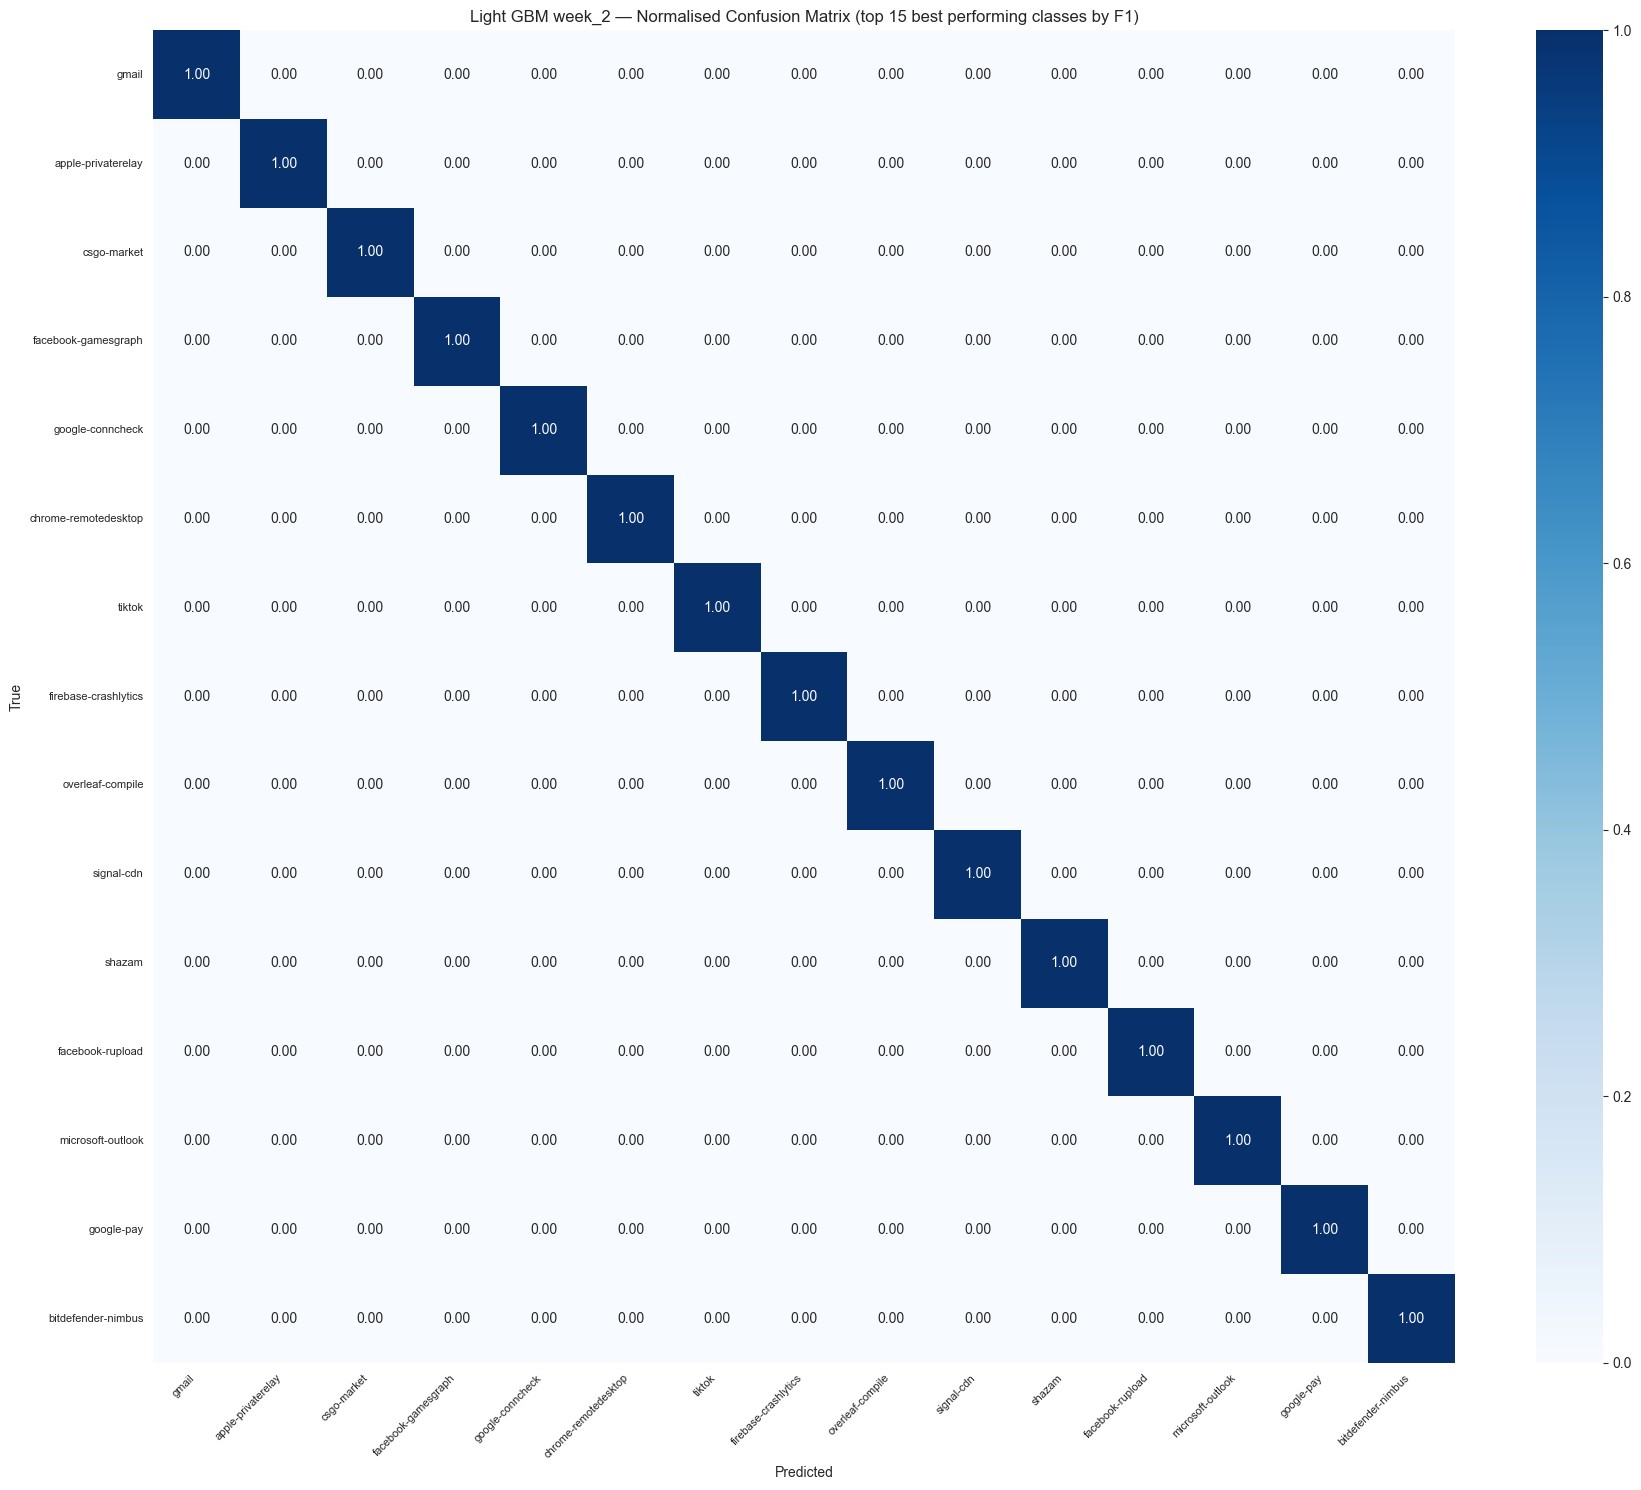

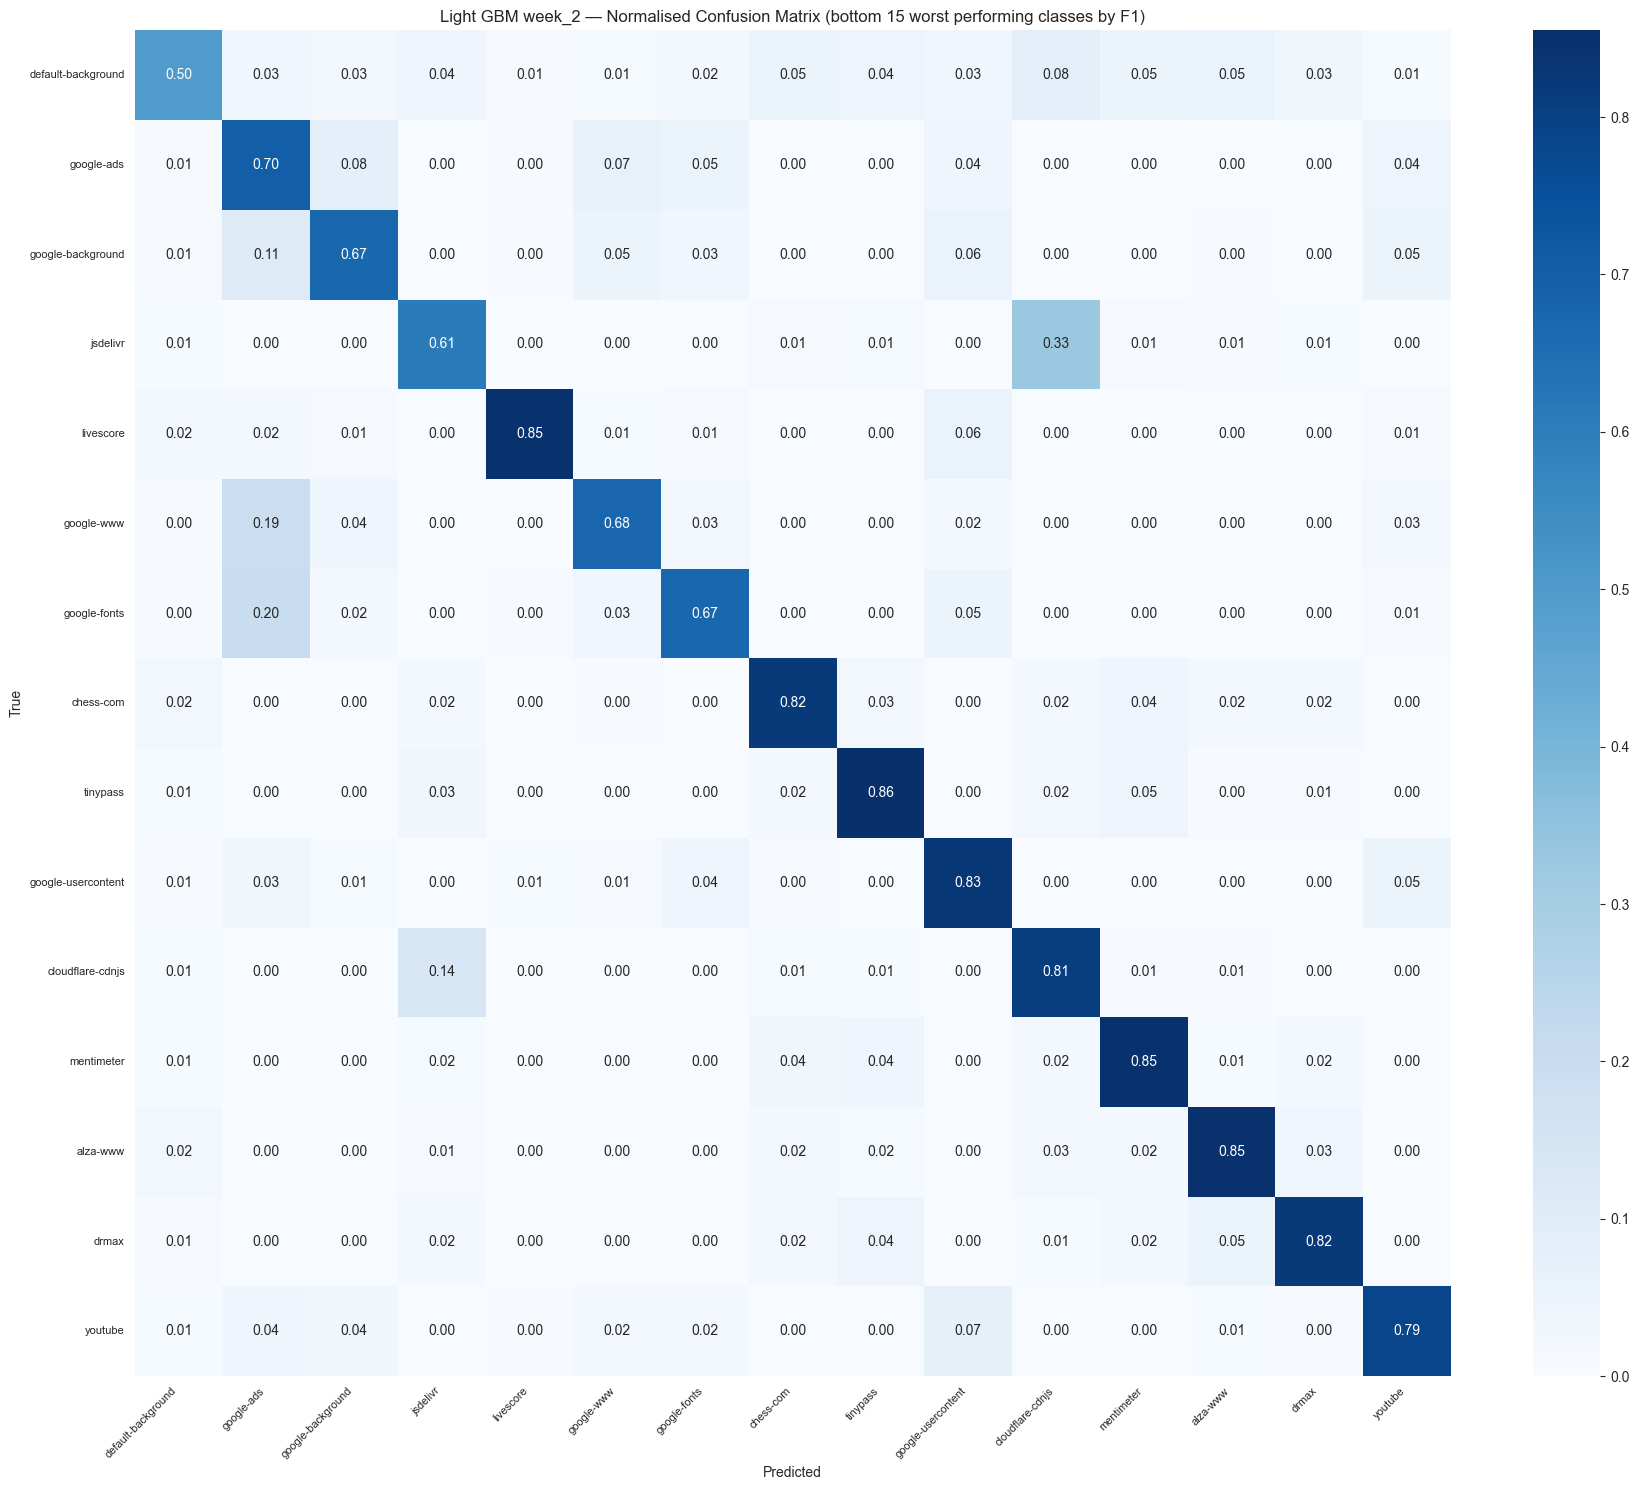



------------------------------------------------------------

Time Elapsed: 5.0m 27.01532745361328s
------- Light GBM week_3 -------
Accuracy    : 0.7261
Macro F1    : 0.7218
Weighted F1 : 0.7246
                       precision    recall  f1-score   support

                4chan       0.68      0.71      0.69      5000
              adavoid       0.79      0.74      0.77      5000
        alza-identity       0.57      0.70      0.63      2355
          alza-webapi       0.80      0.80      0.80      5000
             alza-www       0.52      0.56      0.54      5000
   apple-privaterelay       0.99      0.99      0.99      5000
   bitdefender-nimbus       0.87      0.86      0.86      2276
                bitly       0.88      0.88      0.88      5000
             blitz-gg       0.81      0.72      0.76      5000
              blogger       0.58      0.62      0.60      5000
              cedexis       0.95      0.88      0.91      5000
            chess-com       0.45      0.48   

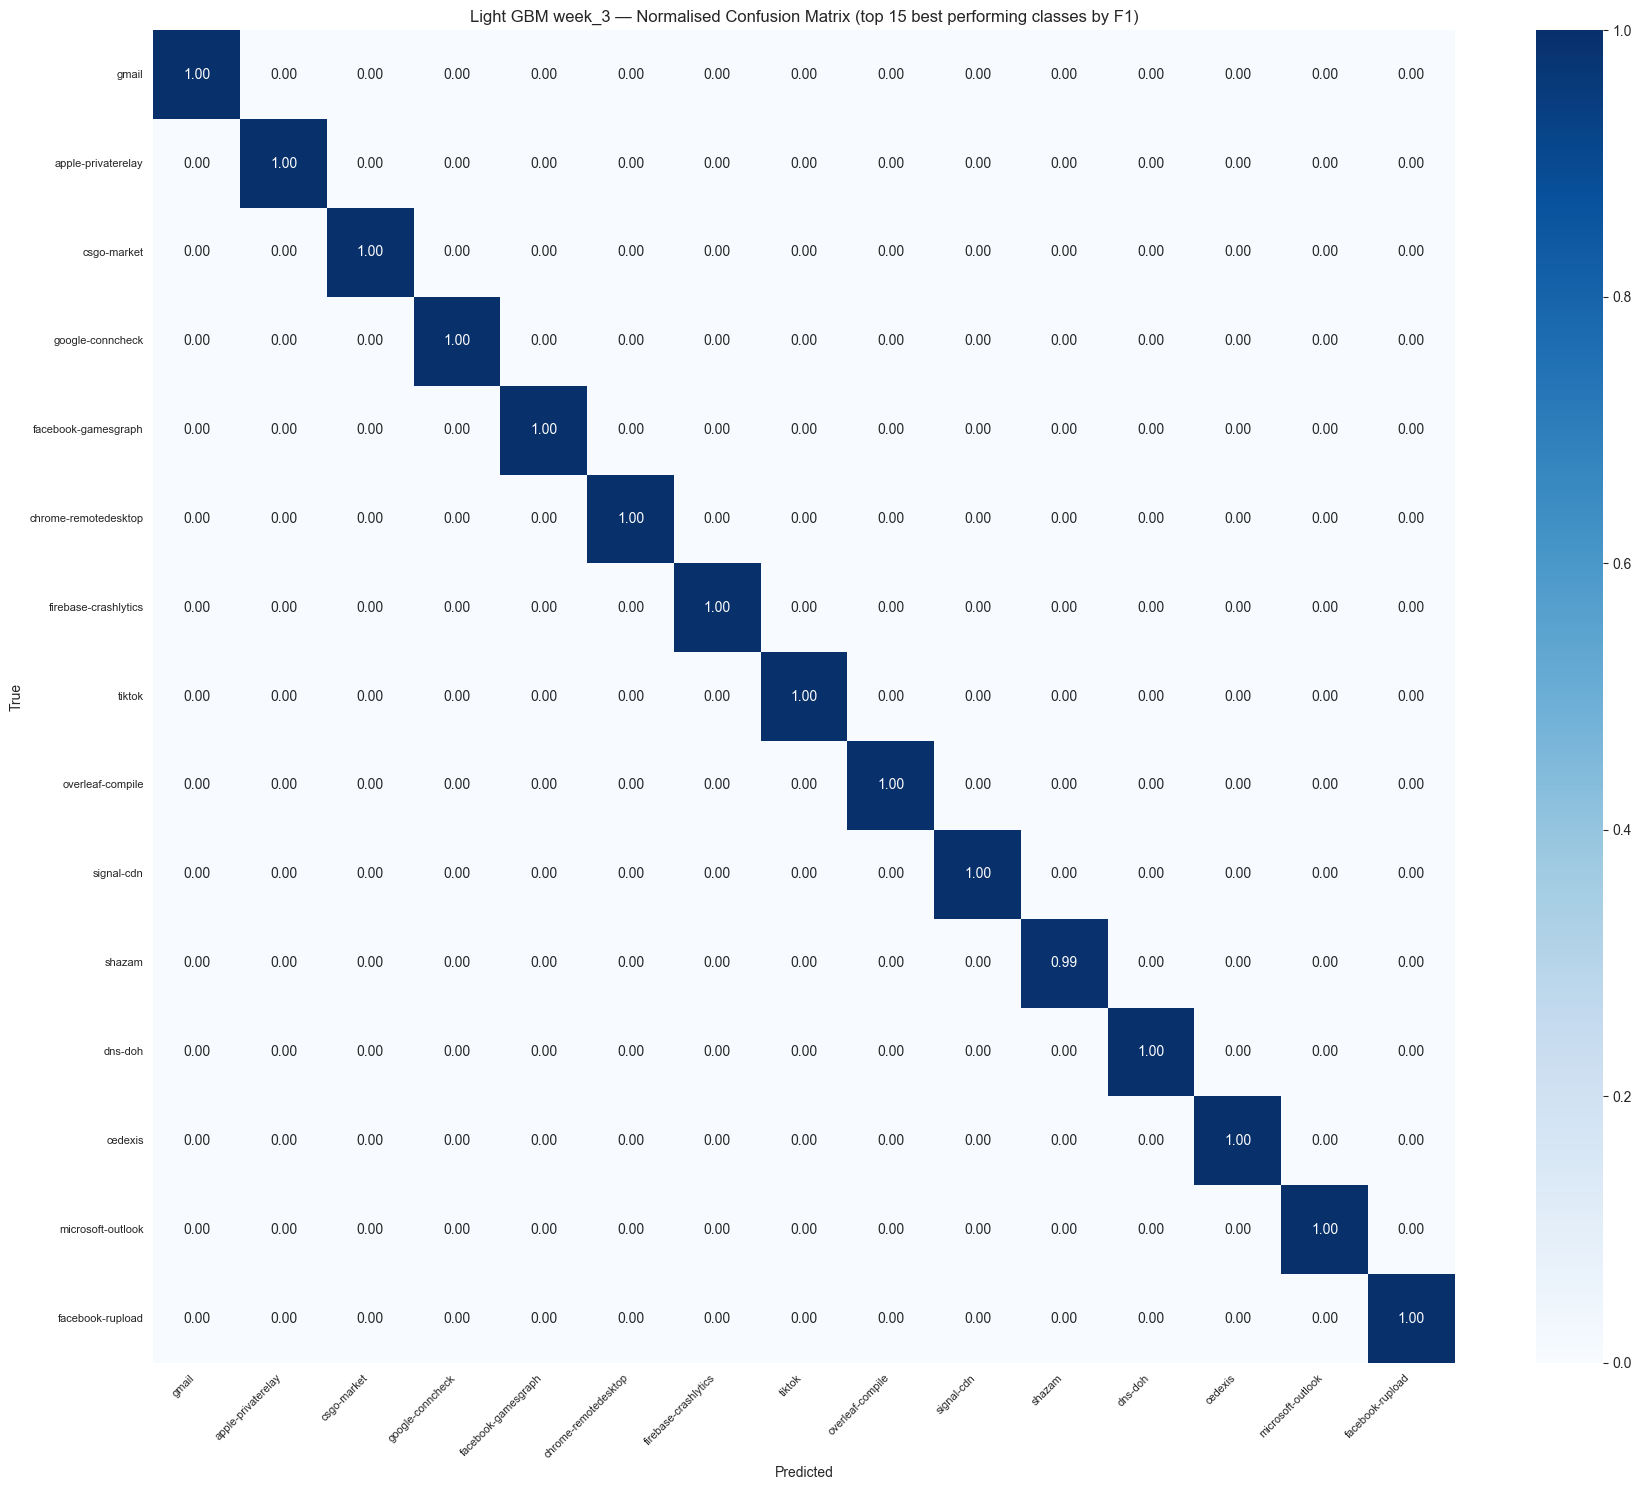

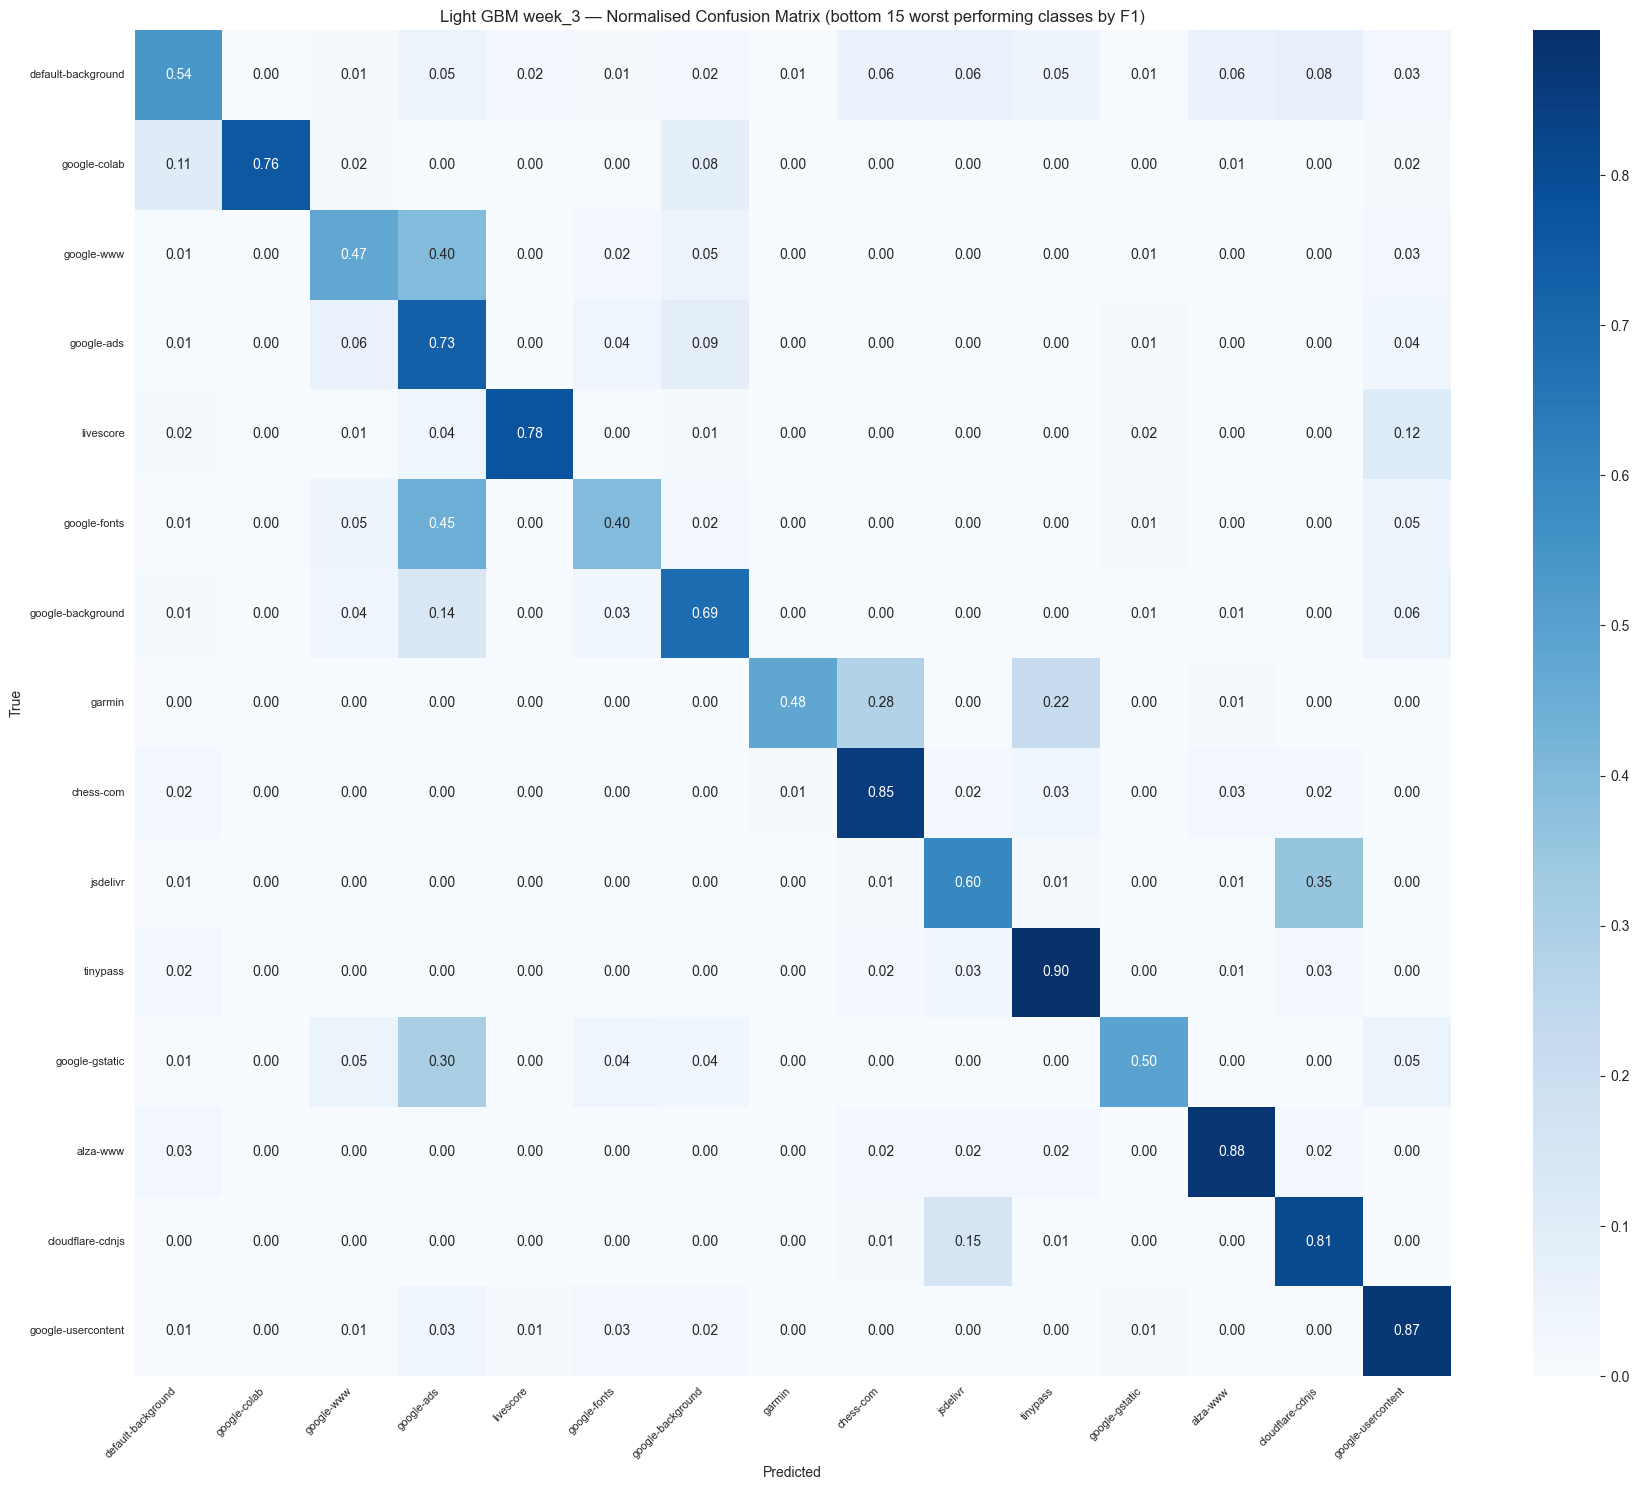



------------------------------------------------------------

Time Elapsed: 5.0m 36.04660630226135s
------- Light GBM week_4 -------
Accuracy    : 0.7224
Macro F1    : 0.7209
Weighted F1 : 0.7210
                       precision    recall  f1-score   support

                4chan       0.65      0.70      0.68      5000
              adavoid       0.84      0.90      0.87      5000
        alza-identity       0.61      0.69      0.65      3049
          alza-webapi       0.78      0.79      0.78      5000
             alza-www       0.53      0.58      0.56      5000
   apple-privaterelay       0.99      0.99      0.99      5000
   bitdefender-nimbus       0.88      0.87      0.88      2782
                bitly       0.89      0.84      0.86      5000
             blitz-gg       0.80      0.66      0.72      5000
              blogger       0.56      0.63      0.59      5000
              cedexis       0.90      0.88      0.89      5000
            chess-com       0.54      0.47   

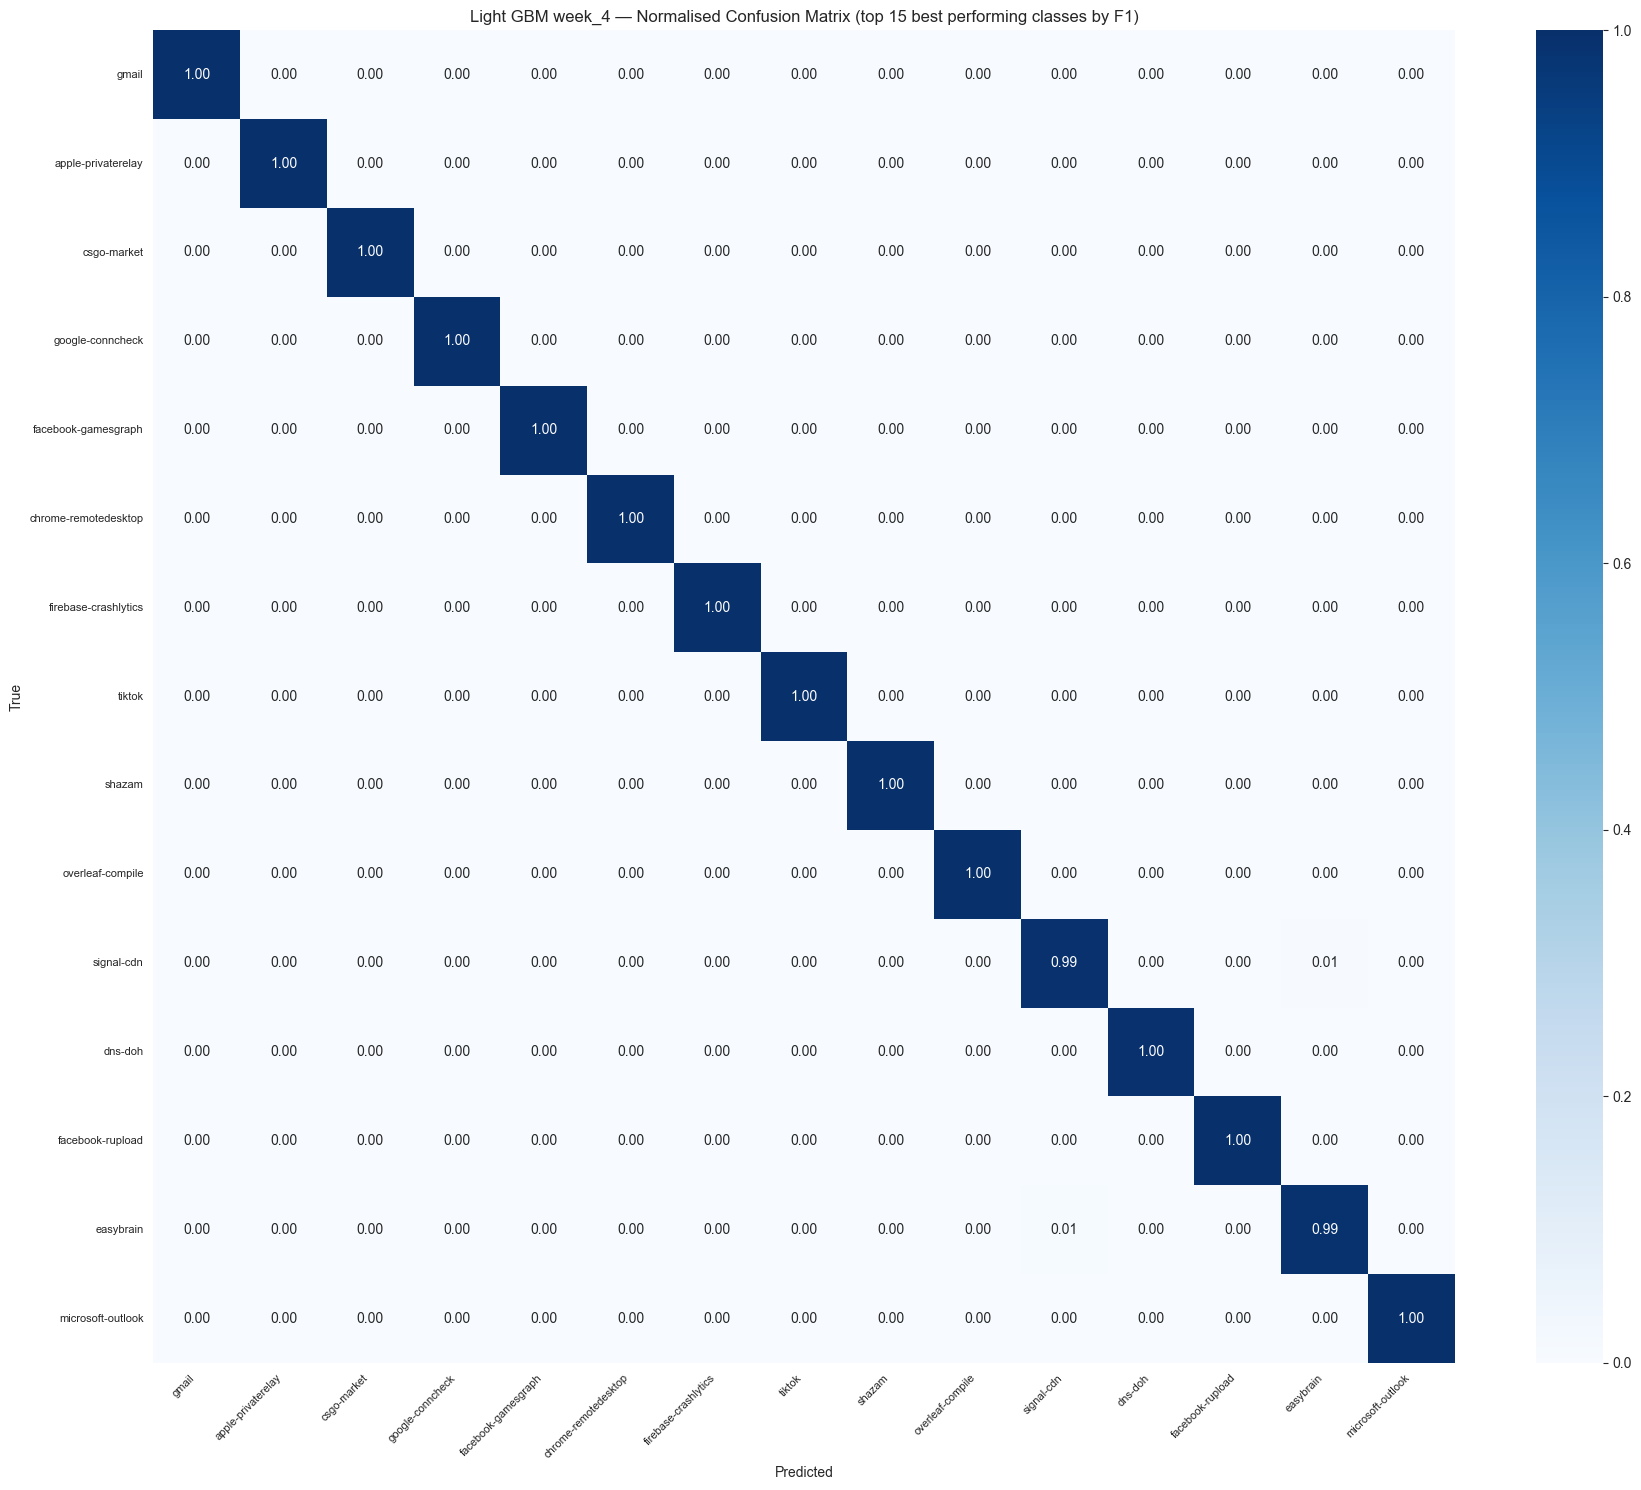

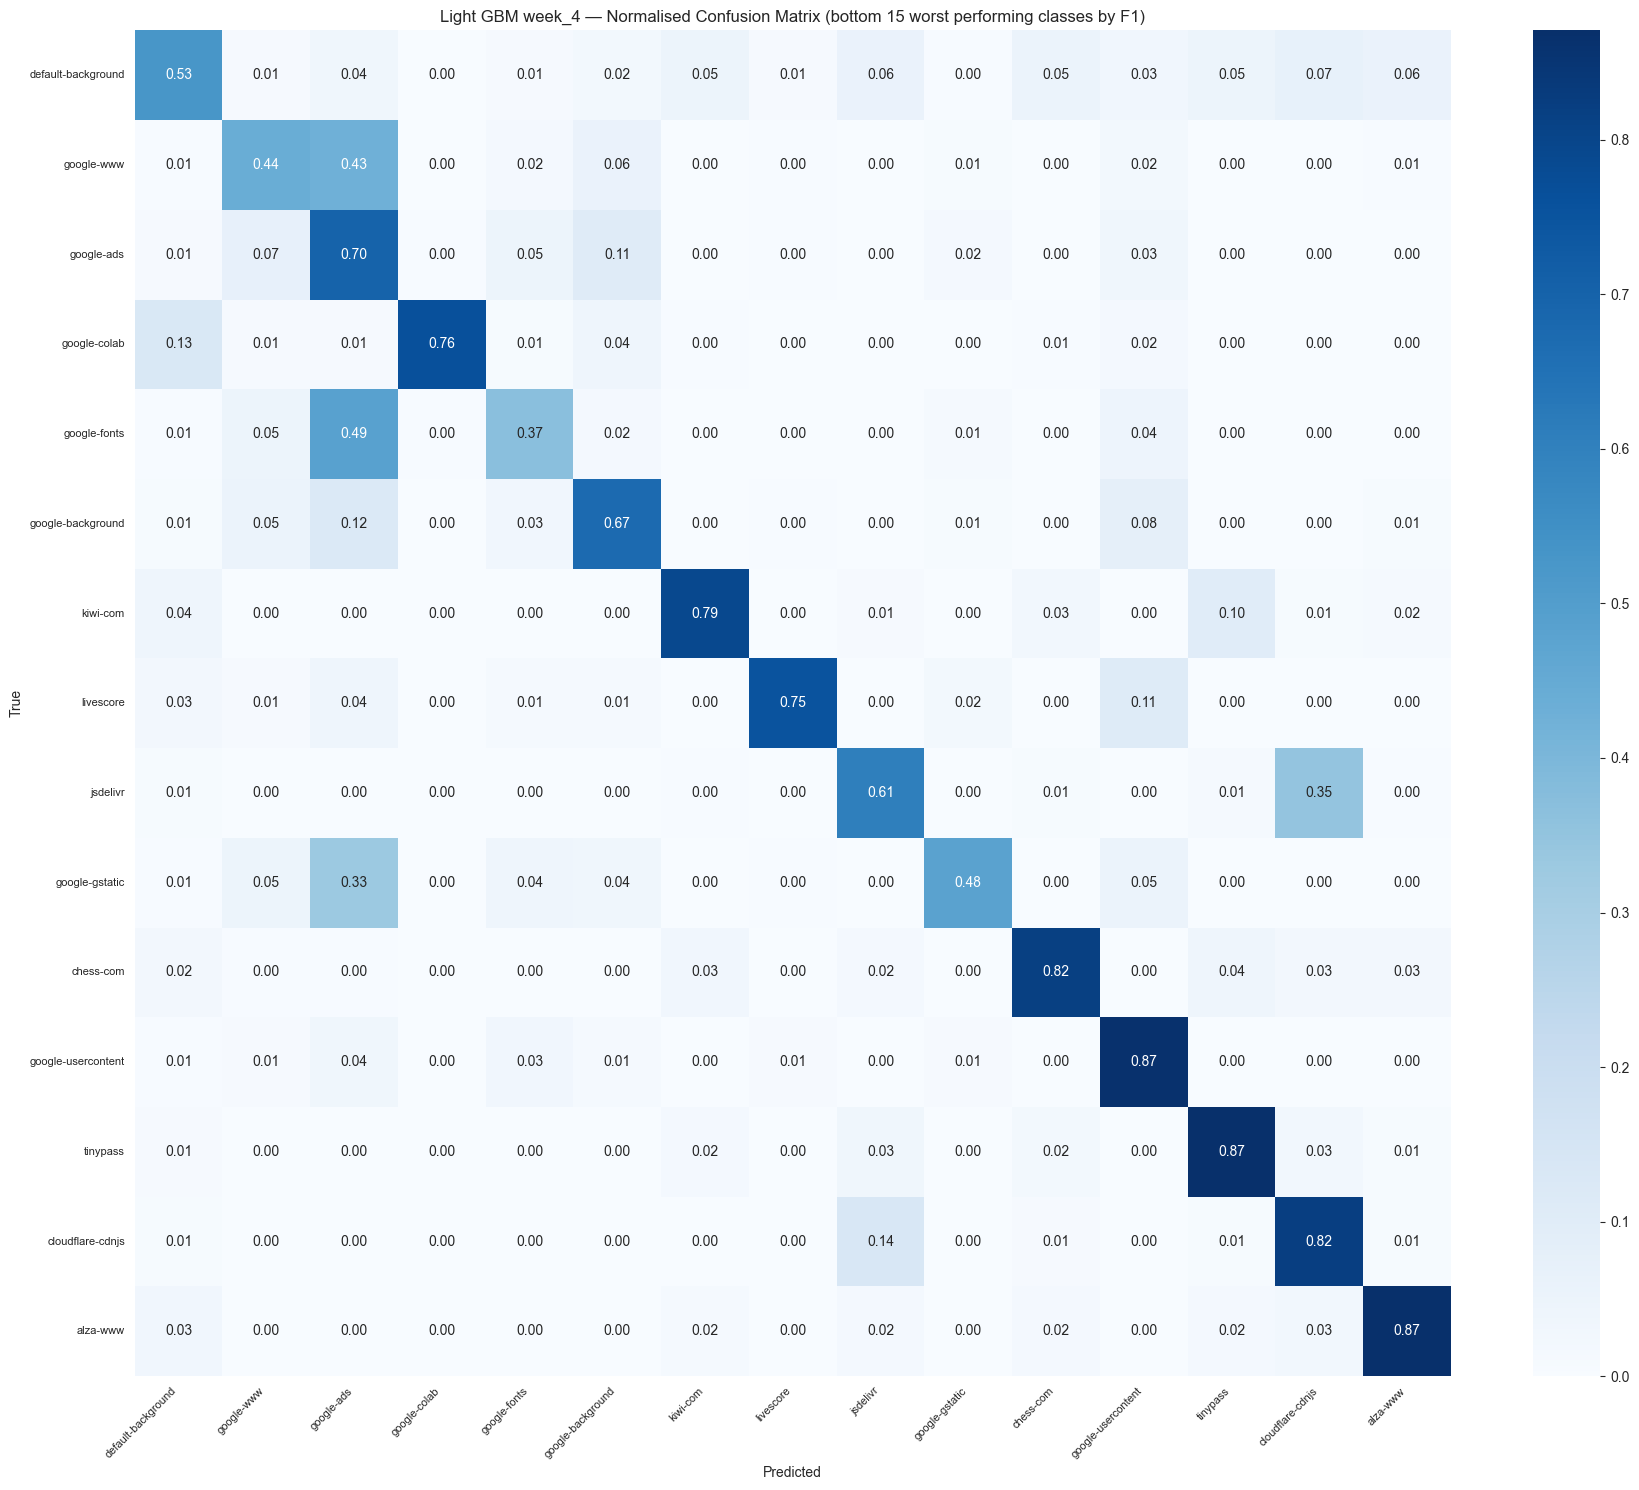



------------------------------------------------------------



In [17]:
weeks_to_test = {
    'week_2': './tabular_dataset/tabular_week_2_sampled.parquet',
    'week_3': './tabular_dataset/tabular_week_3_sampled.parquet',
    'week_4': './tabular_dataset/tabular_week_4_sampled.parquet',
}

for week, path in weeks_to_test.items():
    current_week_df = pd.read_parquet(path)
    X = current_week_df[flow_features + phist_features + endreason_features + ppi_summary_features]
    y = current_week_df['APP']

    timer = Timer()

    y_pred = lightgbm.predict(X)

    timer.stop()

    evaluate_model = Evaluate_model(y_true=y, y_pred=y_pred, modelname=f'Light GBM {week}')
    evaluate_model.get_main_metrics()
    evaluate_model.get_confusion_matrix(on_top=True, num=15)
    evaluate_model.get_confusion_matrix(on_top=False, num=15)
    print('------------------------------------------------------------\n')

### GRU: HyperParameter Tuning

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

torch.set_float32_matmul_precision('medium')

#### 50% Sample Test - 20 trials

In [19]:
X_train, _, y_train, _ = train_test_split(
    seq_bm_X_train, seq_bm_y_train, train_size=0.50, random_state=42, stratify=seq_bm_y_train)

X_tr, X_val, y_tr, y_val = train_test_split(
      X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)

In [20]:
# Creates TensorDataset from X and Y and loads into DataLoader
def to_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# Loads datasets into model
train_loader = to_loader(X_tr,  y_tr,  shuffle=True)
val_loader   = to_loader(X_val, y_val)

In [21]:
import optuna
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

def objective_gru(trial):
    hidden_size    = trial.suggest_int("hidden_size", 32, 256, step=32)
    learning_rate  = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    dropout        = trial.suggest_float("dropout", 0.1, 0.5)
    batch_size     = trial.suggest_categorical("batch_size", [128, 256, 512])

    train_loader_s1 = to_loader(X_tr, y_tr, batch_size=batch_size, shuffle=True)
    val_loader_s2   = to_loader(X_val, y_val, batch_size=batch_size)

    class GRUTrial(L.LightningModule):
        def __init__(self):
            # Layers defined here
            super().__init__()
            self.gru     = nn.GRU(num_features, hidden_size, batch_first=True)
            self.drop    = nn.Dropout(dropout)
            self.fc1     = nn.Linear(hidden_size, 64)
            self.fc2     = nn.Linear(64, num_classes)
            self.loss_fn = nn.CrossEntropyLoss()

        def forward(self, x):
            out, _ = self.gru(x)
            out = self.drop(out[:, -1, :])
            out = self.drop(torch.relu(self.fc1(out)))
            return self.fc2(out)

        def training_step(self, batch, _):
            x, y = batch
            loss = self.loss_fn(self(x), y)
            self.log("train_loss", loss)
            return loss

        def validation_step(self, batch, _):
            x, y = batch
            preds = self(x)
            loss  = self.loss_fn(preds, y)
            acc   = (preds.argmax(1) == y).float().mean()
            self.log_dict({"val_loss": loss, "val_acc": acc})

        def configure_optimizers(self):
            return torch.optim.Adam(self.parameters(), lr=learning_rate)

    model   = GRUTrial()
    trainer = L.Trainer(
        max_epochs=15,
        accelerator="gpu",
        devices=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3)],
    )
    trainer.fit(model, train_loader_s1, val_loader_s2)

    return trainer.logged_metrics["val_acc"].item()

study = optuna.create_study(direction="maximize")
study.optimize(objective_gru, n_trials=20, timeout=1200)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)


[I 2026-04-17 12:10:43,236] A new study created in memory with name: no-name-68d3fa68-e12a-4ccb-bb53-8431ae1213bc
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\

Best params: {'hidden_size': 224, 'learning_rate': 0.0011132864014449298, 'dropout': 0.1435139399764354, 'batch_size': 128}
Best val acc: 0.7059374451637268


#### GRU Best Model on Week 1

In [22]:
# Creates TensorDataset from X and Y and loads into DataLoader
def to_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# Loads datasets into model
train_loader = to_loader(seq_bm_X_train,  seq_bm_y_train,  shuffle=True)
val_loader   = to_loader(seq_bm_X_test, seq_bm_y_test)

In [23]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

class GRU(L.LightningModule):
    def __init__(self, num_classes, hidden_size=128, dropout=0.10123525771214088, learning_rate=1e-3):
        super().__init__()
        self.learning_rate = learning_rate
        self.gru     = nn.GRU(3, hidden_size, batch_first=True)
        self.drop    = nn.Dropout(p=dropout)
        self.fc1     = nn.Linear(hidden_size, 64)
        self.fc2     = nn.Linear(64, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.drop(out[:, -1, :])
        out = self.drop(torch.relu(self.fc1(out)))
        return self.fc2(out)

    def training_step(self, batch, _):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        preds = self(x)
        loss  = self.loss_fn(preds, y)
        acc   = (preds.argmax(1) == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

In [24]:
best_gru_params = study.best_params

gru_model = GRU(
    num_classes=num_classes,
    hidden_size=best_gru_params['hidden_size'],
    dropout=best_gru_params['dropout'],
    learning_rate=best_gru_params['learning_rate'],
)

timer = Timer()

trainer = L.Trainer(
    max_epochs=30,
    accelerator="gpu",
    devices=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, verbose=True)],
)

trainer.fit(gru_model, train_loader, val_loader)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gru     │ GRU              │  153 K │ train │     0 │
│ 1 │ drop    │ Dropout          │      0 │ train │     0 │
│ 2 │ fc1     │ Linear           │ 14.4 K │ train │     0 │
│ 3 │ fc2     │ Linear           │  6.8 K │ train │     0 │
│ 4 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 175 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 175 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connect
or.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value
of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connect
or.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

Metric val_loss improved. New best score: 1.832
Metric val_loss improved by 0.374 >= min_delta = 0.0. New best score: 1.458
Metric val_loss improved by 0.201 >= min_delta = 0.0. New best score: 1.257
Metric val_loss improved by 0.115 >= min_delta = 0.0. New best score: 1.142
Metric val_loss improved by 0.063 >= min_delta = 0.0. New best score: 1.079
Metric val_loss improved by 0.025 >= min_delta = 0.0. New best score: 1.053
Metric val_loss improved by 0.064 >= min_delta = 0.0. New best score: 0.990
Metric val_loss improved by 0.013 >= min_delta = 0.0. New best score: 0.977
Metric val_loss improved by 0.044 >= min_delta = 0.0. New best score: 0.933
Metric val_loss improved by 0.011 >= min_delta = 0.0. New best score: 0.922
Metric val_loss improved by 0.020 >= min_delta = 0.0. New best score: 0.902
Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 0.888
Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.880
Metric val_loss improved by 0.003 >= min

Time Elapsed: 8.0m 25.396219491958618s


Time Elapsed: 16.0m 15.494475603103638s
------- GRU -------
Accuracy    : 0.7639
Macro F1    : 0.7591
Weighted F1 : 0.7606
                       precision    recall  f1-score   support

                4chan       0.60      0.62      0.61      1500
              adavoid       0.79      0.92      0.85      1500
        alza-identity       0.70      0.59      0.64       743
          alza-webapi       0.56      0.74      0.64      1500
             alza-www       0.51      0.56      0.53      1500
   apple-privaterelay       0.99      1.00      1.00      1500
   bitdefender-nimbus       0.84      0.88      0.86       843
                bitly       0.91      0.90      0.90      1500
             blitz-gg       0.82      0.78      0.80      1500
              blogger       0.84      0.76      0.80      1500
              cedexis       0.86      0.90      0.88      1500
            chess-com       0.51      0.33      0.40      1500
 chrome-remotedesktop       0.97      0.98      0.97     

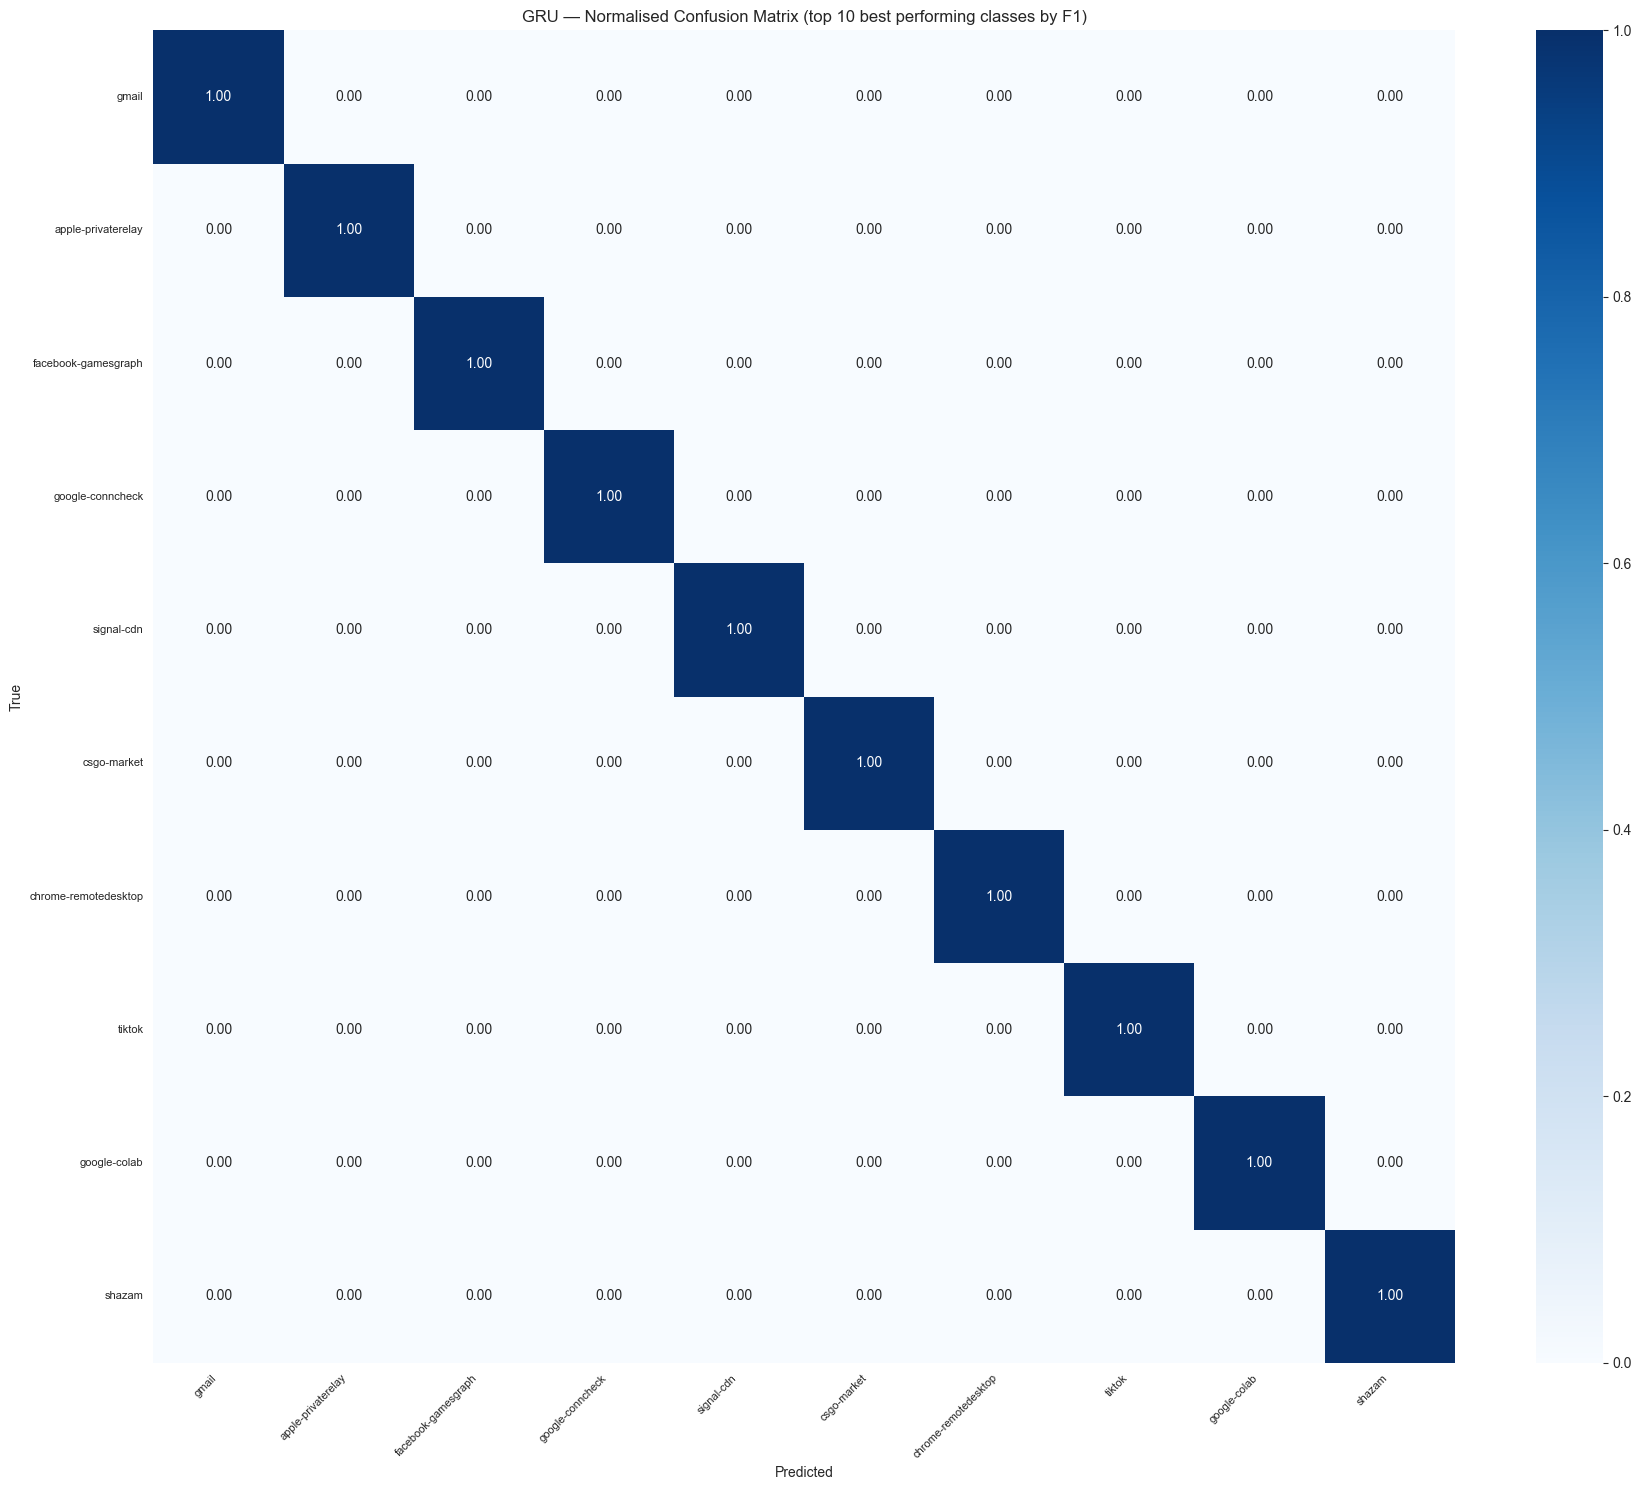

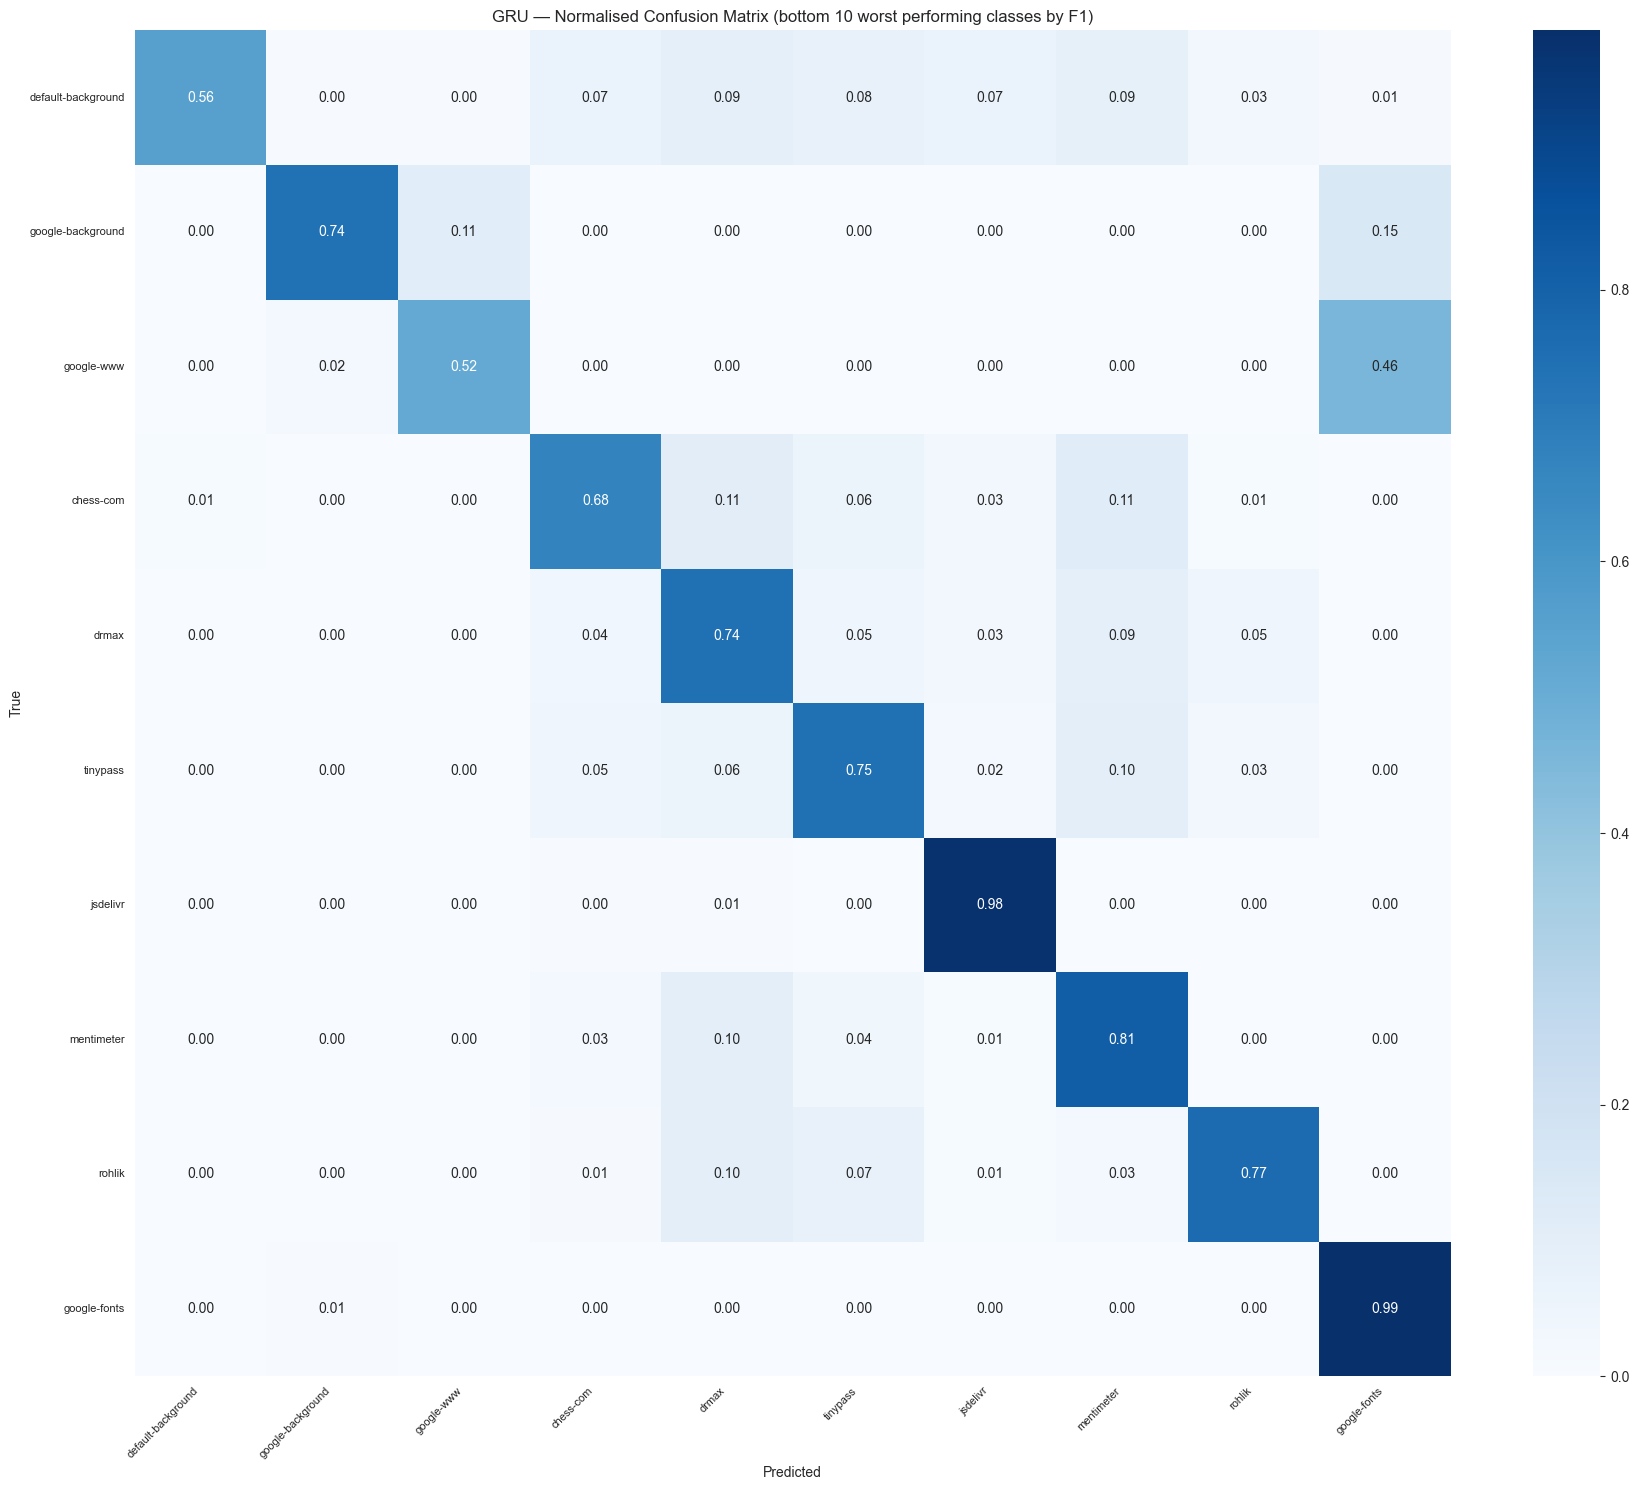

In [27]:
import numpy as np

gru_model.eval()
gru_preds = []
device = next(gru_model.parameters()).device
with torch.no_grad():
    for x, _ in val_loader:
        gru_preds.extend(gru_model(x.to(device)).argmax(dim=1).cpu().numpy())
gru_preds = np.array(gru_preds)

timer.stop()

gru_results = Evaluate_model(seq_bm_y_test, gru_preds, modelname="GRU")
gru_results.get_main_metrics()
gru_results.get_confusion_matrix(on_top=True, num=10)
gru_results.get_confusion_matrix(on_top=False, num=10)


### Soft Voting Ensembler: LightGBM and GRU - with best hyperparameters for both

In [28]:
import torch
import torch.nn.functional as F
import numpy as np

def ensemble_predict_proba(lgb, gru, X_tabular, X_sequence):
    # RF probabilities
    rf_probs = rf.predict_proba(X_tabular)

    # GRU probabilities
    device = next(gru.parameters()).device
    gru.eval()
    with torch.no_grad():
        x = torch.tensor(X_sequence, dtype=torch.float32).to(device)
        logits = gru(x)
        gru_probs = F.softmax(logits, dim=1).cpu().numpy()

    # Average (equal weight)
    return (rf_probs + gru_probs) / 2

timer = Timer()
probs = ensemble_predict_proba(lgb, gru_model, tab_bm_X_test, seq_bm_X_test)
timer.stop()
preds = probs.argmax(axis=1)

Time Elapsed: 1.0m 40.59824085235596s


------- Ensemble -------
Accuracy    : 0.8198
Macro F1    : 0.8144
Weighted F1 : 0.8163
                       precision    recall  f1-score   support

                4chan       0.71      0.76      0.73      1500
              adavoid       0.85      0.95      0.90      1500
        alza-identity       0.76      0.66      0.71       743
          alza-webapi       0.75      0.83      0.79      1500
             alza-www       0.62      0.69      0.65      1500
   apple-privaterelay       1.00      1.00      1.00      1500
   bitdefender-nimbus       0.89      0.91      0.90       843
                bitly       0.91      0.91      0.91      1500
             blitz-gg       0.88      0.88      0.88      1500
              blogger       0.85      0.80      0.83      1500
              cedexis       0.88      0.91      0.89      1500
            chess-com       0.67      0.43      0.52      1500
 chrome-remotedesktop       0.97      0.98      0.98      1500
     cloudflare-cdnjs       0

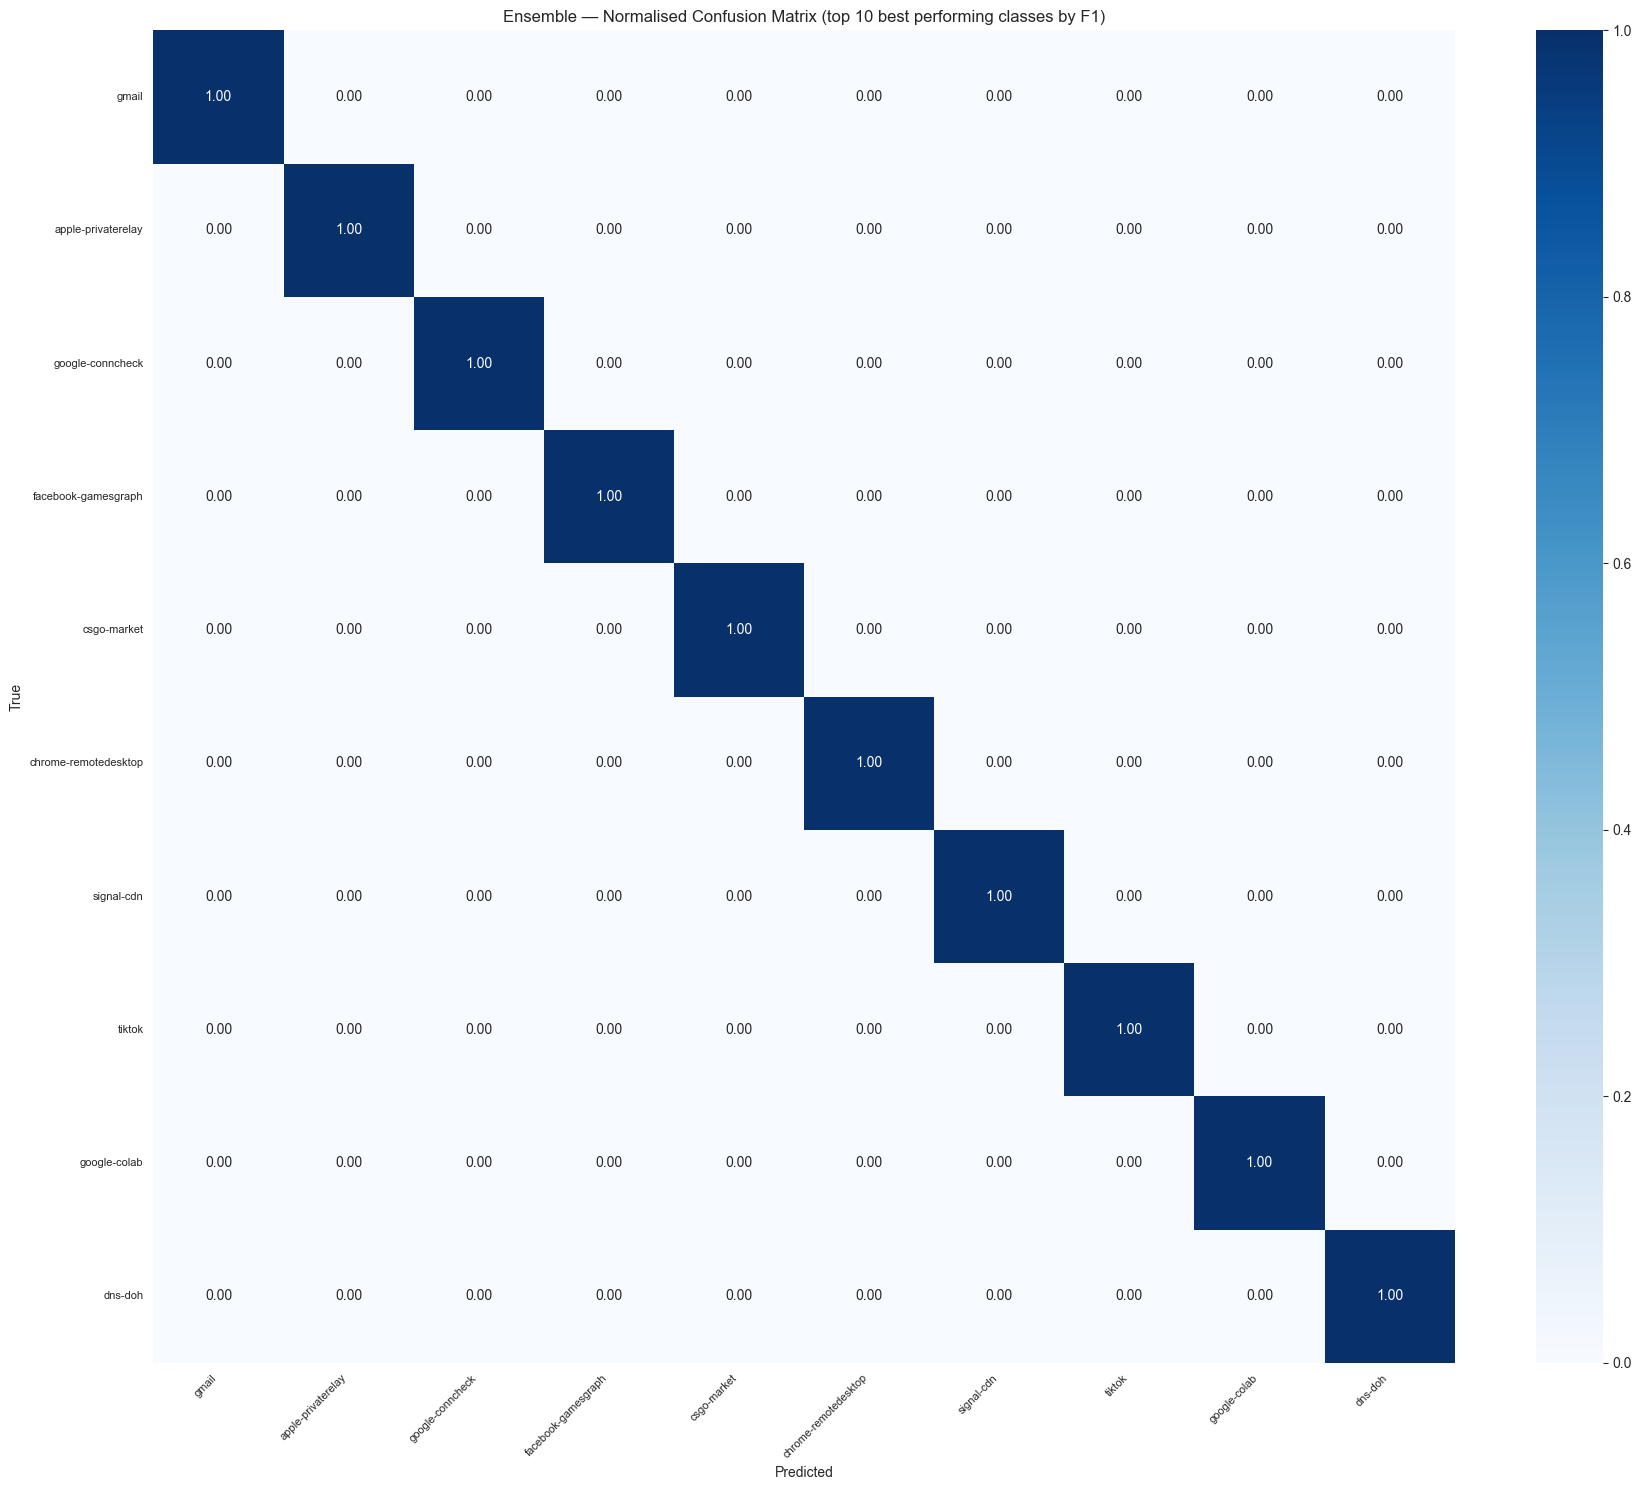

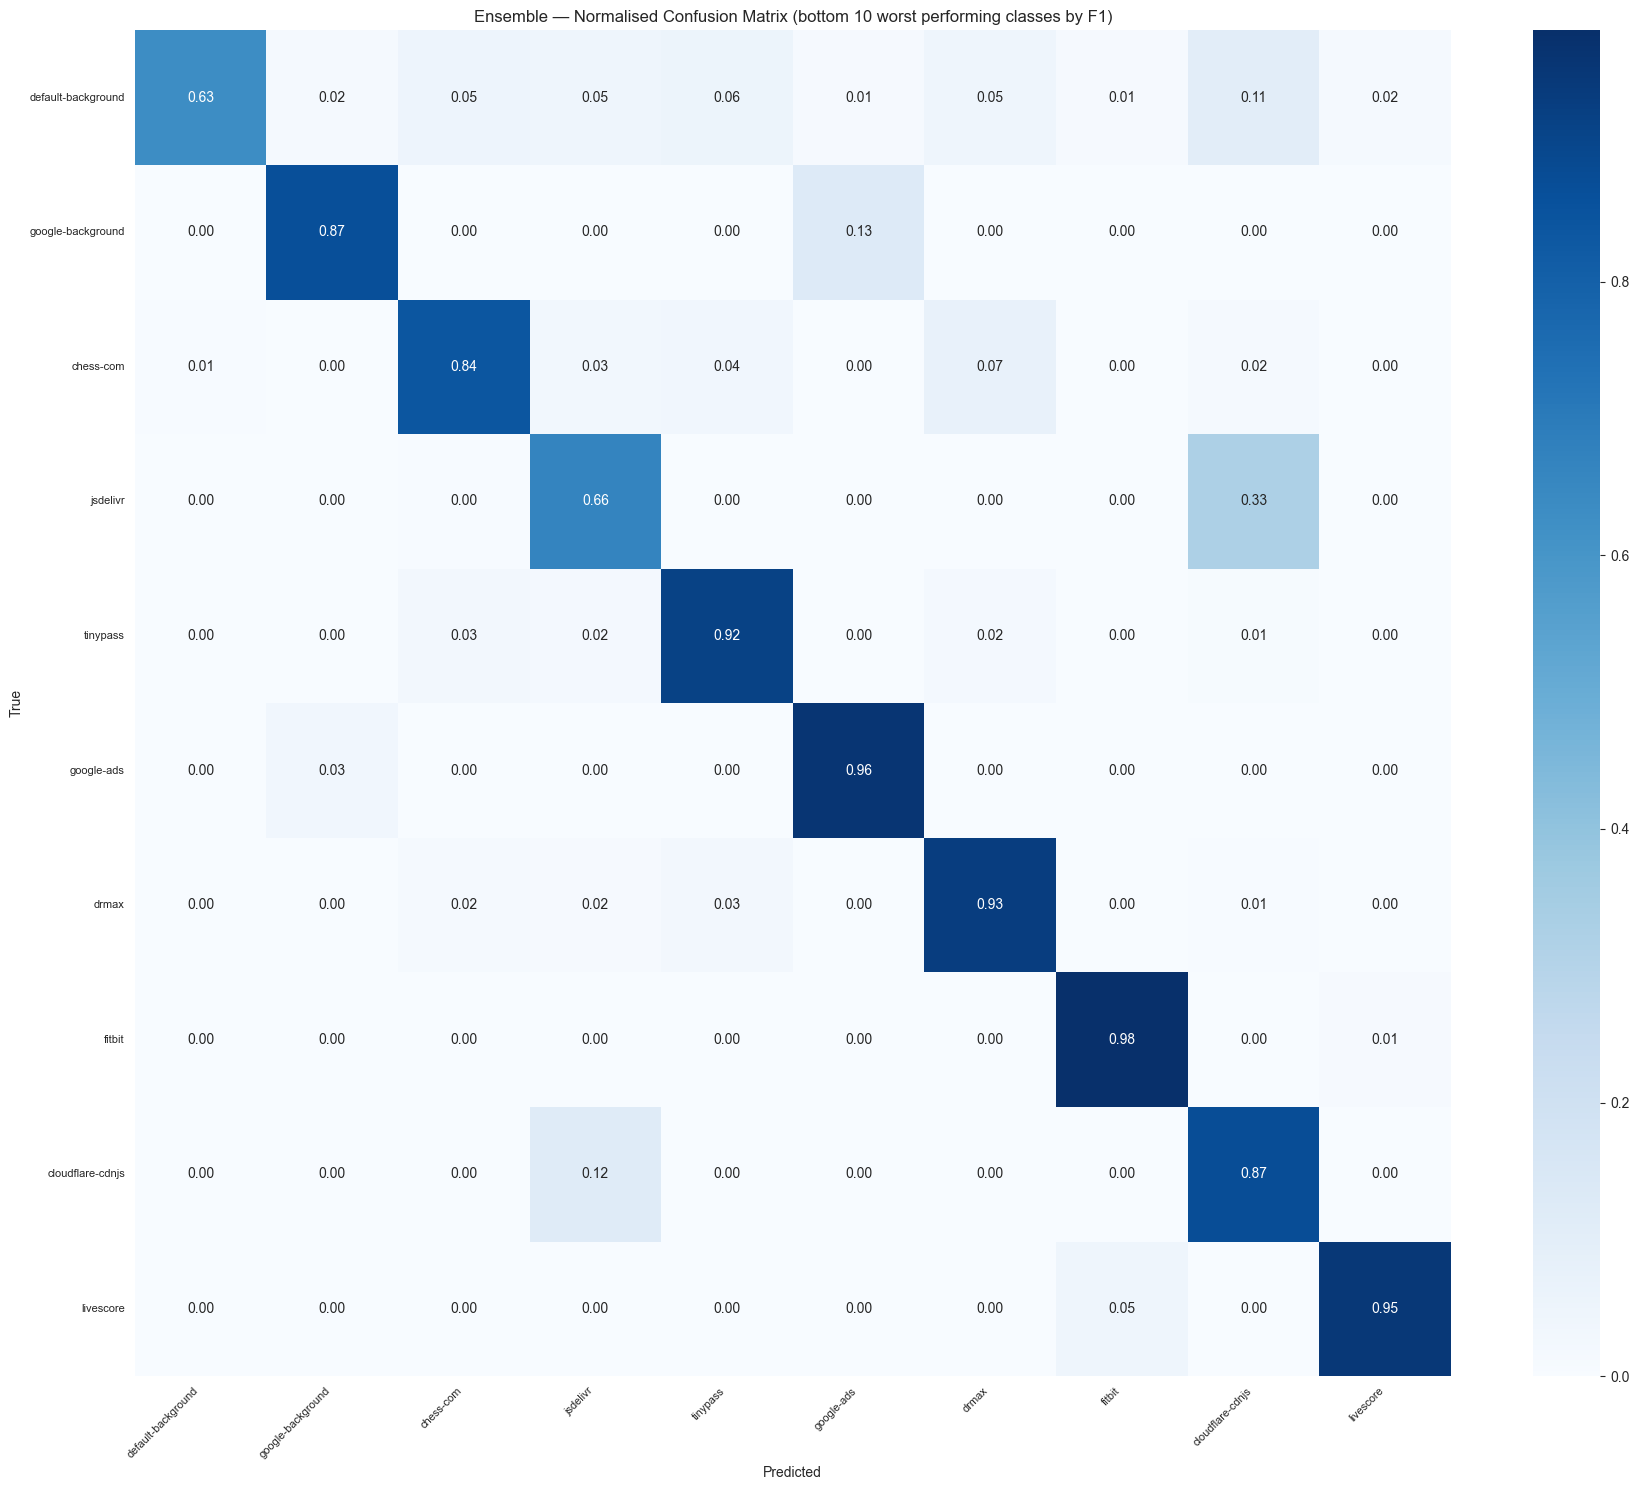

In [29]:
softvote_results = Evaluate_model(tab_bm_y_test.values, preds, modelname="Ensemble")
softvote_results.get_main_metrics()
softvote_results.get_confusion_matrix(on_top=True, num=10)
softvote_results.get_confusion_matrix(on_top=False, num=10)
